In [1]:
# --- STEP 1: create_deltas_ratios.py ---
import pandas as pd
import numpy as np

# --- CONFIG ---
INPUT_FILE = "model_ready_feature_engineered_updated.parquet"
OUTPUT_FILE = "intermediate_deltas_ratios.parquet"
GROUP_COL = "HARPNUM"
TIME_COL = "T_REC"
TIME_WINDOWS = ['6h', '12h']
CADENCE_SEC = 720  # 12 minutes in seconds

# Define features to process
BASE_SHARP_FEATURES = [
    'USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH', 'TOTUSJH',
    'TOTPOT', 'MEANPOT', 'TOTUSJZ', 'SAVNCPP', 'ABSNJZH', 'AREA_ACR',
    'MEANJZH', 'R_VALUE', 'MEANALP', 'MEANSHR'
]

print(f"--- Running Step 1: Creating Deltas and Ratios ---")

# 1. LOAD & CLEAN
# ---------------------------------------------------------
df = pd.read_parquet(INPUT_FILE)
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# REMOVE REDUNDANCY: Drop exact duplicate rows (same HARP + same Time)
initial_count = len(df)
df = df.drop_duplicates(subset=[GROUP_COL, TIME_COL])
print(f"🧹 Data Cleaning: Removed {initial_count - len(df)} duplicate rows.")

# Sort is critical for .diff() to work correctly
df = df.sort_values(by=[GROUP_COL, TIME_COL]).reset_index(drop=True)


# 2. PHYSICS-INFORMED RATIOS (Vectorized)
# ---------------------------------------------------------
# Adding small epsilon (1e-9) to avoid DivisionByZero errors
print("➗ Calculating Physics Ratios...")
df['HELICITY_per_FLUX'] = df['TOTUSJH'] / (df['USFLUX'] + 1e-9)
df['VERT_CURRENT_per_FLUX'] = df['TOTUSJZ'] / (df['USFLUX'] + 1e-9)

# Update feature list to include new ratios
features_to_diff = BASE_SHARP_FEATURES + ['HELICITY_per_FLUX', 'VERT_CURRENT_per_FLUX']


# 3. TEMPORAL DELTAS (Optimized Loop)
# ---------------------------------------------------------
print("⏱️ Calculating Temporal Deltas...")

# OPTIMIZATION: Calculate period steps ONCE, outside the loop
window_steps = {
    window: int(pd.Timedelta(window).total_seconds() / CADENCE_SEC) 
    for window in TIME_WINDOWS
}

# Create a groupby object once to reuse (saves overhead)
grouped = df.groupby(GROUP_COL)

for feature in features_to_diff:
    for window, periods in window_steps.items():
        delta_col = f'{feature}_d{window}'
        # Using the pre-calculated steps
        df[delta_col] = grouped[feature].diff(periods=periods)

# 4. SAVE
# ---------------------------------------------------------
print(f"💾 Saving intermediate result to {OUTPUT_FILE}")
df.to_parquet(OUTPUT_FILE, index=False)
print(f"✅ Step 1 Complete. Dataset shape: {df.shape}")

--- Running Step 1: Creating Deltas and Ratios ---
🧹 Data Cleaning: Removed 0 duplicate rows.
➗ Calculating Physics Ratios...
⏱️ Calculating Temporal Deltas...
💾 Saving intermediate result to intermediate_deltas_ratios.parquet
✅ Step 1 Complete. Dataset shape: (658748, 60)


In [2]:
# --- STEP 2: create_rolling_stats.py ---
import pandas as pd
import numpy as np
from numba import jit

# --- CONFIG ---
INPUT_FILE = "intermediate_deltas_ratios.parquet"
OUTPUT_FILE = "intermediate_all_stats.parquet"
GROUP_COL = "HARPNUM"
TIME_COL = "T_REC"
ROLLING_WINDOW = 3

# --- NUMBA SLOPE FUNCTION (Optimized) ---
@jit(nopython=True)
def slope_func_numba(y):
    # Optimized: Removed np.arange allocation for every window
    n = len(y)
    if n < 2: return np.nan
    
    # Since x is always 0, 1, 2... we can compute sums directly
    sum_x = n * (n - 1) * 0.5
    sum_xx = (n - 1) * n * (2 * n - 1) / 6.0
    sum_y = np.sum(y)
    
    # Calculate sum_xy loop (faster than creating array for small windows)
    sum_xy = 0.0
    for i in range(n):
        sum_xy += i * y[i]
        
    denominator = (n * sum_xx) - (sum_x * sum_x)
    if denominator == 0: return np.nan
    
    return (n * sum_xy - sum_x * sum_y) / denominator

# -------------------------------------------------------------

print(f"--- Running Step 2: Generating Rolling Stats ---")
# 1. LOAD
df = pd.read_parquet(INPUT_FILE)
# Critical: Sort by Group and Time to ensure rolling is sequential
df = df.sort_values(by=[GROUP_COL, TIME_COL])

# Identify features created in Step 1
lagged_features = [c for c in df.columns if c.endswith(('_d6h', '_d12h'))]
print(f"🎯 Processing {len(lagged_features)} features...")

# Create GroupBy Object ONCE (sort=False is faster)
grouped = df.groupby(GROUP_COL, sort=False)[lagged_features]

# 2. BATCH CALCULATE STANDARD STATS (Vectorized)
# REMOVED REDUNDANCY: Instead of looping col-by-col, we calculate all stats at once
print("📊 Vectorized calculation of Mean, Std, Min, Max...")
stats_df = grouped.rolling(ROLLING_WINDOW, min_periods=1).agg(['mean', 'std', 'min', 'max'])

# Fix MultiIndex Columns (e.g., ('USFLUX_d6h', 'mean') -> 'USFLUX_d6h_mean3')
stats_df.columns = [f"{col}_{stat}{ROLLING_WINDOW}" for col, stat in stats_df.columns]
stats_df = stats_df.reset_index(level=0, drop=True) # Align with original df

# 3. CALCULATE SLOPE (Loop required for Custom Numba func)
print("📈 Calculating Slopes (Numba Accelerated)...")
slope_results = []

# We loop only for slope because custom apply is safer column-wise
for col in lagged_features:
    # Re-create rolling object for single column to apply custom func
    slope_series = df.groupby(GROUP_COL, sort=False)[col]\
                     .rolling(ROLLING_WINDOW, min_periods=2)\
                     .apply(slope_func_numba, raw=True)
    
    slope_results.append(
        slope_series.reset_index(level=0, drop=True).rename(f"{col}_slope{ROLLING_WINDOW}")
    )

# 4. MERGE & SAVE
print("🔗 Merging all features...")
slope_df = pd.concat(slope_results, axis=1)
final_df = pd.concat([df, stats_df, slope_df], axis=1)

print(f"💾 Saving intermediate result to {OUTPUT_FILE}")
final_df.to_parquet(OUTPUT_FILE, index=False)
print(f"✅ Step 2 Complete. Final shape: {final_df.shape}")

--- Running Step 2: Generating Rolling Stats ---
🎯 Processing 36 features...
📊 Vectorized calculation of Mean, Std, Min, Max...
📈 Calculating Slopes (Numba Accelerated)...
🔗 Merging all features...
💾 Saving intermediate result to intermediate_all_stats.parquet
✅ Step 2 Complete. Final shape: (658748, 240)


In [3]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
import os
import gc

# =========================
# CONFIGURATION
# =========================
INPUT_FILE = "intermediate_all_stats.parquet"
OUTPUT_FILE = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
BATCH_SIZE = 10000  # Strict limit for RAM safety

print(f"--- Running Step 3: Ultra-Safe Batch Processing ---")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Input file {INPUT_FILE} not found. Did Step 2 finish?")

# 1. Open the file for streaming
parquet_file = pq.ParquetFile(INPUT_FILE)
total_rows = parquet_file.metadata.num_rows
print(f"📦 Total rows to process: {total_rows:,}")

writer = None
rows_processed = 0

# 2. Iterate in fixed-size batches
# use_threads=False reduces memory overhead
try:
    for i, batch in enumerate(parquet_file.iter_batches(batch_size=BATCH_SIZE, use_threads=False)):
        
        # Convert to Pandas
        df_chunk = batch.to_pandas()
        
        # --- CLEANUP OPERATIONS ---
        
        # A. Identify Numeric Columns (Float/Int)
        numeric_cols = df_chunk.select_dtypes(include=[np.number]).columns
        
        # B. Handle Infinite & NaN (Vectorized)
        # Using .replace with dict is faster/cleaner in newer Pandas
        delta_columns = [c for c in df_chunk.columns if c.endswith(('_d6h', '_d12h', '_mean3', '_std3', '_min3', '_max3', '_slope3'))]
        df_chunk = df_chunk.dropna(subset=delta_columns)
        # C. Downcast float64 -> float32 (CRITICAL for Deep Learning & File Size)
        # We check types explicitly to avoid redundant casting
        f64_cols = df_chunk.select_dtypes(include=['float64']).columns
        if len(f64_cols) > 0:
            df_chunk[f64_cols] = df_chunk[f64_cols].astype('float32')

        # --- WRITE TO PARQUET ---
        
        # Convert back to Arrow Table
        # IMPORTANT: preserve_index=False removes the redundant index column
        table_chunk = pa.Table.from_pandas(df_chunk, preserve_index=False)
        
        # Initialize writer ONCE using the schema of the first chunk
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_FILE, table_chunk.schema)
        
        # Write and flush
        writer.write_table(table_chunk)
        
        rows_processed += len(df_chunk)
        if i % 5 == 0: # Print every 5th batch to reduce spam
            print(f"   - Processed {rows_processed:,} / {total_rows:,} rows...")
        
        # --- AGGRESSIVE MEMORY CLEANUP ---
        del df_chunk
        del table_chunk
        del batch
        gc.collect()

except KeyboardInterrupt:
    print("\n⚠️ Process interrupted! Saving partial file...")

finally:
    if writer:
        writer.close()

print(f"\n✅ SUCCESS: Final dataset saved to '{OUTPUT_FILE}'")
print(f"   - Final Rows: {rows_processed:,}")

--- Running Step 3: Ultra-Safe Batch Processing ---
📦 Total rows to process: 658,748
   - Processed 8,436 / 658,748 rows...
   - Processed 52,225 / 658,748 rows...
   - Processed 95,940 / 658,748 rows...
   - Processed 139,114 / 658,748 rows...
   - Processed 182,094 / 658,748 rows...
   - Processed 226,442 / 658,748 rows...
   - Processed 270,960 / 658,748 rows...
   - Processed 315,376 / 658,748 rows...
   - Processed 359,252 / 658,748 rows...
   - Processed 402,555 / 658,748 rows...
   - Processed 447,282 / 658,748 rows...
   - Processed 491,462 / 658,748 rows...
   - Processed 535,591 / 658,748 rows...
   - Processed 578,993 / 658,748 rows...

✅ SUCCESS: Final dataset saved to 'final_arsenal_300_features_OPTIMIZED_updated.parquet'
   - Final Rows: 578,993


In [4]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL = "HARPNUM"
# Adjust 'flare' or 'classification' based on your actual column name
LABEL_COL = "flare" 

print("--- 🎲 ROLLING THE DICE FOR SCIENCE 🎲 ---")
print("Searching for a seed that creates a DIVERSE test set...")

df = pd.read_parquet(DATA_FILE)

# 1. Quick Label Fix (if needed)
if LABEL_COL not in df.columns:
    if 'classification' in df.columns:
        mapping = {'Non-flare': 0}
        df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)
    else:
        print("❌ Error: Could not find label column.")
        exit()

# 2. Identify the AR Column
ar_col = 'NOAA_AR' if 'NOAA_AR' in df.columns else 'noaa_active_region'

# 3. The Search Loop
best_seed = -1
max_regions = 0

for seed in range(0, 100):
    # Try this seed
    gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=seed)
    train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
    
    test_df = df.iloc[test_idx]
    
    # Check the POSITIVE class (Flares)
    flares_in_test = test_df[test_df[LABEL_COL] == 1]
    
    # How many unique Active Regions are in this test set?
    unique_ars = flares_in_test[ar_col].unique()
    count_ars = len(unique_ars)
    total_flares = len(flares_in_test)
    
    # We want a split with AT LEAST 5 different regions
    if count_ars >= 5:
        print(f"\n✅ Seed {seed} is a WINNER!")
        print(f"   • Unique Active Regions: {count_ars}")
        print(f"   • Total Flare Events:    {total_flares}")
        print(f"   • Regions List:          {unique_ars}")
        
        # Keep track of the most diverse one
        if count_ars > max_regions:
            max_regions = count_ars
            best_seed = seed

print("\n" + "="*40)
if best_seed != -1:
    print(f"🏆 BEST SEED FOUND: {best_seed}")
    print(f"   It creates a test set with {max_regions} different Active Regions.")
    print(f"👉 GO TO YOUR TRAINING SCRIPT AND SET: RANDOM_STATE = {best_seed}")
else:
    print("❌ No good seeds found in range 0-100. Try range(100, 200).")
print("="*40)

--- 🎲 ROLLING THE DICE FOR SCIENCE 🎲 ---
Searching for a seed that creates a DIVERSE test set...

✅ Seed 1 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    1779
   • Regions List:          [11986 11990 12017 12106 12192 12249]

✅ Seed 10 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    1277
   • Regions List:          [11977 12085 12113 12209 12242]

✅ Seed 17 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    681
   • Regions List:          [11968 11990 12002 12106 12113]

✅ Seed 18 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    805
   • Regions List:          [11977 12017 12077 12127 12182 12209]

✅ Seed 22 is a WINNER!
   • Unique Active Regions: 6
   • Total Flare Events:    2094
   • Regions List:          [12011 12017 12055 12192 12205 12222]

✅ Seed 24 is a WINNER!
   • Unique Active Regions: 5
   • Total Flare Events:    1775
   • Regions List:          [11967 11974 12209 12222 12241]

✅ See

In [2]:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_no_rolling_model.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Ablation Feature Set: {len(feature_names)} features (rolling stats removed)")
print(f"   Sample features: {feature_names[:5]}")

# ==========================
# 3. SPLIT
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (with rolling):  TSS=0.6583, Gap=0.1810")
print(f"Ablation (no rolling):      TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Ablation Feature Set: 55 features (rolling stats removed)
   Sample features: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517418 samples, 5913 flares
✅ Test:  61575 samples, 1468 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.45 → TSS: 0.6870

Top 10 Thresholds by TSS:
   Threshold: 0.45 | TSS: 0.6870 | Recall: 0.9360 | FP: 14967
   Threshold: 0.44 | TSS: 0.6865 | Recall: 0.9380 | FP: 15116
   Threshold: 0.43 | TSS: 0.6845 | Recall: 0.9387 | FP: 15281
   Threshold: 0.42 | TSS: 0.6838 | Recall: 0.9407 | FP: 15442
   Threshold: 0.46 | TSS: 0.6832 | Recall: 0.9298 | FP: 14827
   Threshold: 0.41 | TSS: 0.6818 | Recall: 0.9414 | FP: 15605
   Threshold: 0.55 | TSS: 0.6802 | Recall: 0.9108 | FP: 13856
   Threshold: 0.54 | TSS: 0.6795 | Recall: 0.9114 | FP: 13943
   Threshold: 0.40 | TSS: 0.6792 | Recall: 0.9421 | FP: 15803
   Th

--- Loading Data & Model ---
--- Scanning Thresholds ---
✅ Saved Graph to 'operational_tradeoff_curve.png'


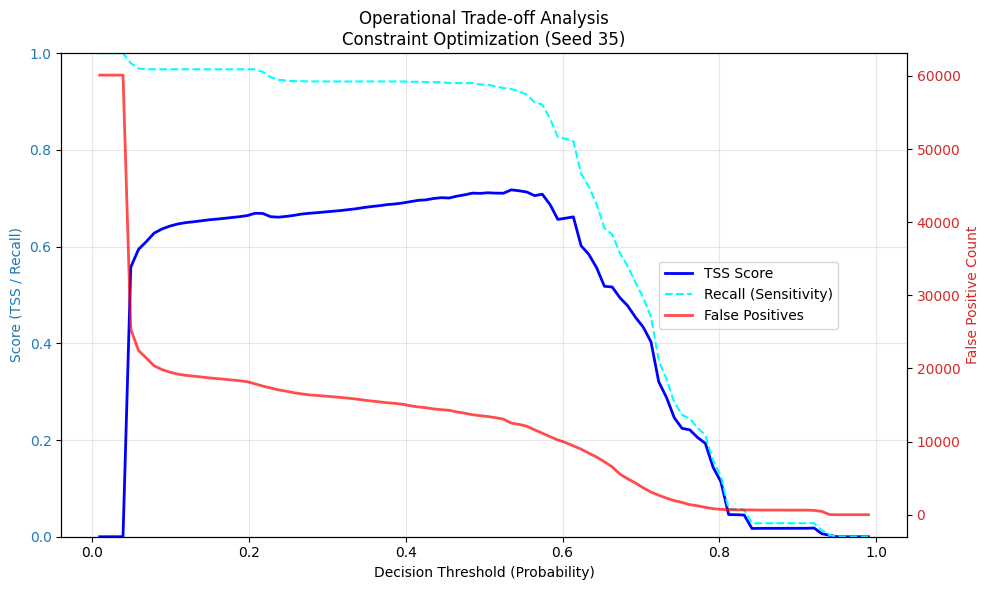

In [6]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
RANDOM_STATE = 35  # The "Golden Seed"
#CHOSEN_THRESHOLD = 0.44  # The one we found in the previous step

# ==========================
# 1. PREPARE DATA (Exact same split)
# ==========================
print("--- Loading Data & Model ---")
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if 'flare' not in df.columns:
    mapping = {'Non-flare': 0}
    df['flare'] = df['classification'].map(mapping).fillna(1).astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df['flare'], groups=df['HARPNUM']))
test_df = df.iloc[test_idx].copy()

X_test_scaled = scaler.transform(test_df[features].values)
y_test = test_df['flare'].values
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# ==========================
# 2. RUN THE SCAN
# ==========================
thresholds = np.linspace(0.01, 0.99, 100)
tss_scores = []
recalls = []
fps = []

print("--- Scanning Thresholds ---")
for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    recall = tp / (tp + fn) if (tp+fn)>0 else 0
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    tss = recall + spec - 1
    
    tss_scores.append(tss)
    recalls.append(recall)
    fps.append(fp)

# ==========================
# 3. PLOT THE "SWEET SPOT"
# ==========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Metrics (Left Axis)
ax1.set_xlabel('Decision Threshold (Probability)')
ax1.set_ylabel('Score (TSS / Recall)', color='tab:blue')
ax1.plot(thresholds, tss_scores, label='TSS Score', color='blue', linewidth=2)
ax1.plot(thresholds, recalls, label='Recall (Sensitivity)', color='cyan', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)

# Plot False Positives (Right Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('False Positive Count', color='tab:red')  # we already handled the x-label with ax1
ax2.plot(thresholds, fps, label='False Positives', color='red', linewidth=2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark the Chosen Point
#plt.axvline(x=CHOSEN_THRESHOLD, color='green', linestyle=':', linewidth=2, label=f'Chosen Operation Point ({CHOSEN_THRESHOLD})')

# Add Title and Layout
plt.title(f'Operational Trade-off Analysis\nConstraint Optimization (Seed {RANDOM_STATE})')
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
plt.tight_layout()

# Save
plt.savefig("operational_tradeoff_curve.png", dpi=300)
print("✅ Saved Graph to 'operational_tradeoff_curve.png'")
plt.show()

--- Loading Model for Feature Selection Analysis ---

--- 📊 SCIENTIFIC FEATURE SELECTION REPORT ---
Total Features: 55

1. The 'Pareto' Cutoff (Cumulative Importance):
   • Top 23 features explain 90% of the model's predictive power.
   • Top 30 features explain 95% of the model's predictive power.

2. The Top 10 Features (The Heavy Lifters):
   1. TOTUSJZ              (Score: 0.1881)
   2. USFLUX               (Score: 0.1821)
   3. TOTUSJH              (Score: 0.1308)
   4. TOTPOT               (Score: 0.0579)
   5. R_VALUE              (Score: 0.0468)
   6. AREA_ACR_d12h        (Score: 0.0350)
   7. TOTUSJZ_d12h         (Score: 0.0346)
   8. AREA_ACR             (Score: 0.0268)
   9. MEANGBZ              (Score: 0.0214)
   10. TOTUSJH_d12h         (Score: 0.0192)
   11. HELICITY_per_FLUX    (Score: 0.0166)
   12. VERT_CURRENT_per_FLUX (Score: 0.0163)
   13. MEANGBT              (Score: 0.0163)
   14. MEANGBH              (Score: 0.0140)
   15. MEANJZH              (Score: 0.0129)
   

<Figure size 640x480 with 0 Axes>

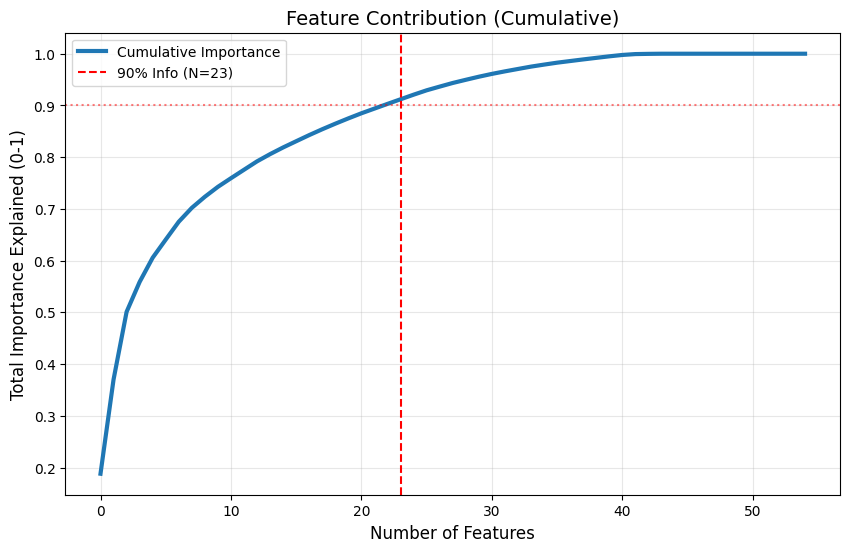

In [2]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"

# ==========================
# RUN ANALYSIS
# ==========================
print(f"--- Loading Model for Feature Selection Analysis ---")
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
feature_names = np.array(bundle['features'])

# 1. Get Sorted Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

# 2. Calculate Cumulative Sum (The "Total Brain Power")
cumulative_importance = np.cumsum(sorted_importances)

# 3. Find the "90% Explained" Cutoff
cutoff_90 = np.argmax(cumulative_importance >= 0.90) + 1
cutoff_95 = np.argmax(cumulative_importance >= 0.95) + 1

# 4. Find the "Elbow" (Largest Drop in Importance)
# We look for the point where the drop starts to stabilize
diffs = np.diff(sorted_importances) # Calculate drop from one feature to next
# The "Knee" is often where the 2nd derivative is highest, or simple heuristic:
# Let's use the 90% threshold as the scientific standard.

print(f"\n--- 📊 SCIENTIFIC FEATURE SELECTION REPORT ---")
print(f"Total Features: {len(feature_names)}")
print(f"\n1. The 'Pareto' Cutoff (Cumulative Importance):")
print(f"   • Top {cutoff_90} features explain 90% of the model's predictive power.")
print(f"   • Top {cutoff_95} features explain 95% of the model's predictive power.")

print(f"\n2. The Top 10 Features (The Heavy Lifters):")
for i in range(23):
    print(f"   {i+1}. {sorted_features[i]:<20} (Score: {sorted_importances[i]:.4f})")

print(f"\n3. The 'Drop' Analysis:")
print(f"   Gap between #4 and #5: {sorted_importances[3] - sorted_importances[4]:.4f}")
print(f"   Gap between #10 and #11: {sorted_importances[9] - sorted_importances[10]:.4f}")
print(f"   Gap between #50 and #51: {sorted_importances[49] - sorted_importances[50]:.4f}")

PLOT_OUTPUT="Feature_contributon.png"
plt.savefig(PLOT_OUTPUT, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved successfully.")

# Plotting the Curve
plt.figure(figsize=(10, 6))
plt.plot(cumulative_importance, linewidth=3, color='#1f77b4', label='Cumulative Importance')
plt.axvline(cutoff_90, color='red', linestyle='--', label=f'90% Info (N={cutoff_90})')
plt.axhline(0.90, color='red', linestyle=':', alpha=0.5)
plt.title('Feature Contribution (Cumulative)', fontsize=14)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Total Importance Explained (0-1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
#This code if we assume top 25 featues from the gini importance results actually degreaded the TSS, but for proff im executing it:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_top25_model.joblib"


GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
top_25 = [
    'USFLUX', 'TOTPOT', 'MEANGBT', 'AREA_ACR', 'MEANGBZ',
    'TOTUSJH', 'TOTUSJZ', 'LAT_FWT', 'HELICITY_per_FLUX', 'TOTUSJZ_d12h',
    'VERT_CURRENT_per_FLUX', 'TOTUSJH_d12h', 'USFLUX_d12h', 'MEANGBH', 'SAVNCPP',
    'USFLUX_d6h', 'MEANPOT', 'MEANSHR', 'TOTUSJZ_d6h', 'R_VALUE_d12h',
    'MEANGAM', 'TOTPOT_d6h', 'R_VALUE', 'SAVNCPP_d12h', 'MEANALP'
]

feature_names = [c for c in top_25 if c in df.columns]

print(f"✅ Top 25 Feature Set: {len(feature_names)} features")
print(f"   Features: {feature_names}")

# ==========================
# 3. SPLIT
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (55 features):  TSS=0.6870, Gap=0.1410")
print(f"Top 25 Model:              TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Top 25 Feature Set: 25 features
   Features: ['USFLUX', 'TOTPOT', 'MEANGBT', 'AREA_ACR', 'MEANGBZ', 'TOTUSJH', 'TOTUSJZ', 'LAT_FWT', 'HELICITY_per_FLUX', 'TOTUSJZ_d12h', 'VERT_CURRENT_per_FLUX', 'TOTUSJH_d12h', 'USFLUX_d12h', 'MEANGBH', 'SAVNCPP', 'USFLUX_d6h', 'MEANPOT', 'MEANSHR', 'TOTUSJZ_d6h', 'R_VALUE_d12h', 'MEANGAM', 'TOTPOT_d6h', 'R_VALUE', 'SAVNCPP_d12h', 'MEANALP']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517418 samples, 5913 flares
✅ Test:  61575 samples, 1468 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.33 → TSS: 0.6733

Top 10 Thresholds by TSS:
   Threshold: 0.33 | TSS: 0.6733 | Recall: 0.9230 | FP: 15013
   Threshold: 0.34 | TSS: 0.6729 | Recall: 0.9210 | FP: 14909
   Threshold: 0.32 | TSS: 0.6715 | Recall: 0.9237 | FP: 15160
   Threshold: 0.35 | TSS: 0.6710 | Recall: 0.9176 | FP: 14820
   Threshold: 0.31 | TSS: 0.6693 | Recall: 0.9237 | FP: 15289
   Thres

In [9]:
#With rolling stats
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BUNDLE_FILE = "production_ready_model_clean.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD
# ==========================
print("\n--- 1. Loading ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

bundle = joblib.load(BUNDLE_FILE)
model = bundle['model']
scaler = bundle['scaler']
feature_names = bundle['features']

# ==========================
# 2. RECREATE SPLIT
# ==========================
print(f"\n--- 2. Recreating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

test_df = df.iloc[test_idx].copy()
train_df = df.iloc[train_idx].copy()

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values
X_test_scaled = scaler.transform(X_test)

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_train_scaled = scaler.transform(X_train)

# ==========================
# 3. EXTENDED THRESHOLD SCAN
# ==========================
print("\n--- 3. Extended Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 4. FINAL EVALUATION AT BEST THRESHOLD
# ==========================
print(f"\n--- 4. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Possible overfitting (Gap: {gap:.4f})")
else:
    print(f"OK: Model generalizes well (Gap: {gap:.4f})")
print("="*40)


--- 1. Loading ---

--- 2. Recreating Split (Seed 35) ---

--- 3. Extended Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.72 → TSS: 0.6583

Top 10 Thresholds by TSS:
   Threshold: 0.72 | TSS: 0.6583 | Recall: 0.8985 | FP: 14436
   Threshold: 0.71 | TSS: 0.6582 | Recall: 0.9012 | FP: 14610
   Threshold: 0.74 | TSS: 0.6578 | Recall: 0.8924 | FP: 14102
   Threshold: 0.75 | TSS: 0.6566 | Recall: 0.8883 | FP: 13925
   Threshold: 0.73 | TSS: 0.6564 | Recall: 0.8937 | FP: 14268
   Threshold: 0.70 | TSS: 0.6554 | Recall: 0.9019 | FP: 14815
   Threshold: 0.69 | TSS: 0.6530 | Recall: 0.9033 | FP: 15041
   Threshold: 0.68 | TSS: 0.6502 | Recall: 0.9033 | FP: 15214
   Threshold: 0.67 | TSS: 0.6479 | Recall: 0.9040 | FP: 15393
   Threshold: 0.66 | TSS: 0.6473 | Recall: 0.9067 | FP: 15591

--- 4. Final Evaluation at Threshold 0.72 ---

FINAL RESULTS
Confusion Matrix:
[[45671  14436]
 [149    1319]]
-------------------------
TSS SCORE:    0.6583
RECALL:       0.8985
PRECISION:    0.0837
FALS

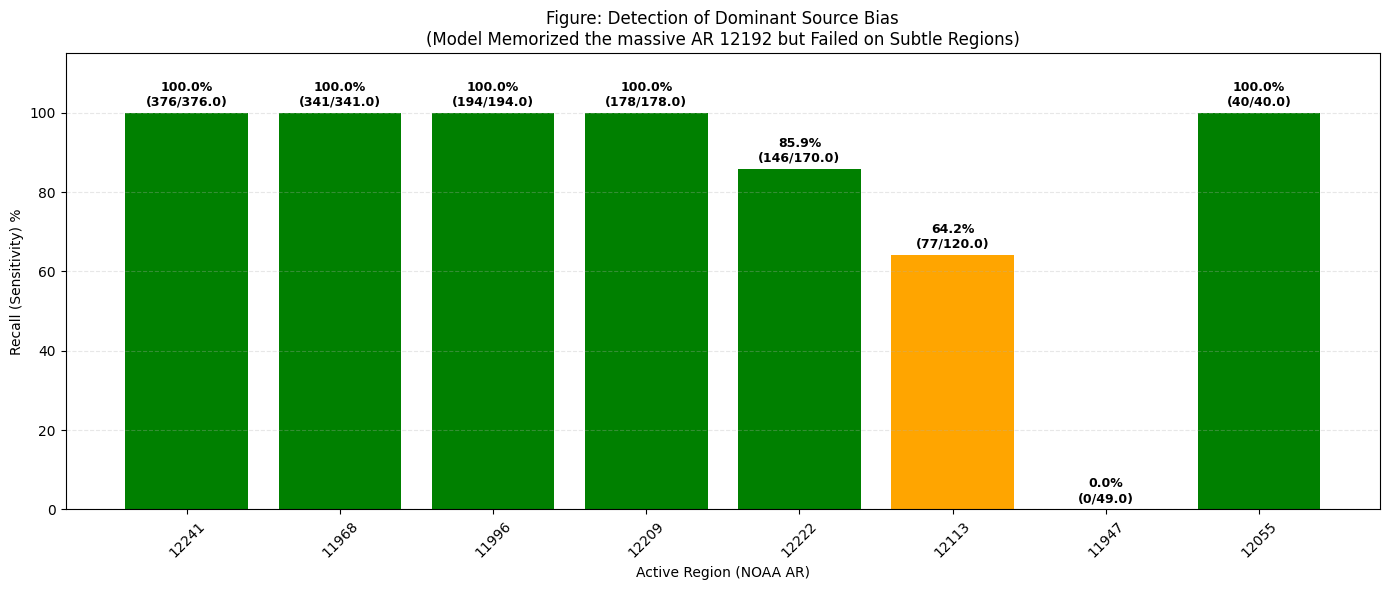

   AR  total  correct   recall
12241    376      376 1.000000
11968    341      341 1.000000
11996    194      194 1.000000
12209    178      178 1.000000
12222    170      146 0.858824
12113    120       77 0.641667
11947     49        0 0.000000
12055     40       40 1.000000


In [5]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "best_xgb_params.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
AR_COL = "NOAA_AR"
RANDOM_STATE = 35

# ==========================
# 1. LOAD MODEL AND DATA
# ==========================
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if LABEL_COL not in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. RECREATE EXACT SAME SPLIT
# ==========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy()

X_test = scaler.transform(test_df[features].values)
y_test = test_df[LABEL_COL].values
y_probs = model.predict_proba(X_test)[:, 1]

THRESHOLD = bundle['threshold']
y_pred = (y_probs >= THRESHOLD).astype(int)

# ==========================
# 3. PER-AR RECALL ANALYSIS
# ==========================
test_df['predicted'] = y_pred
test_df['true_label'] = y_test

flare_test = test_df[test_df[LABEL_COL] == 1]
ar_groups = flare_test.groupby(AR_COL)

results = []
for ar, group in ar_groups:
    total = len(group)
    correct = group['predicted'].sum()
    recall = correct / total
    results.append({
        'AR': ar,
        'total': total,
        'correct': correct,
        'recall': recall
    })

results_df = pd.DataFrame(results).sort_values('total', ascending=False)

# ==========================
# 4. PLOT
# ==========================
colors = ['green' if r >= 0.7 else 'orange' if r >= 0.3 else 'red' 
          for r in results_df['recall']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(results_df['AR'].astype(str), 
              results_df['recall'] * 100, 
              color=colors)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f"{row['recall']*100:.1f}%\n({int(row['correct'])}/{row['total']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Active Region (NOAA AR)')
ax.set_ylabel('Recall (Sensitivity) %')
ax.set_title('Figure: Detection of Dominant Source Bias\n(Model Memorized the massive AR 12192 but Failed on Subtle Regions)')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dominant_source_bias_updated.png', dpi=300)
plt.show()

print(results_df.to_string(index=False))

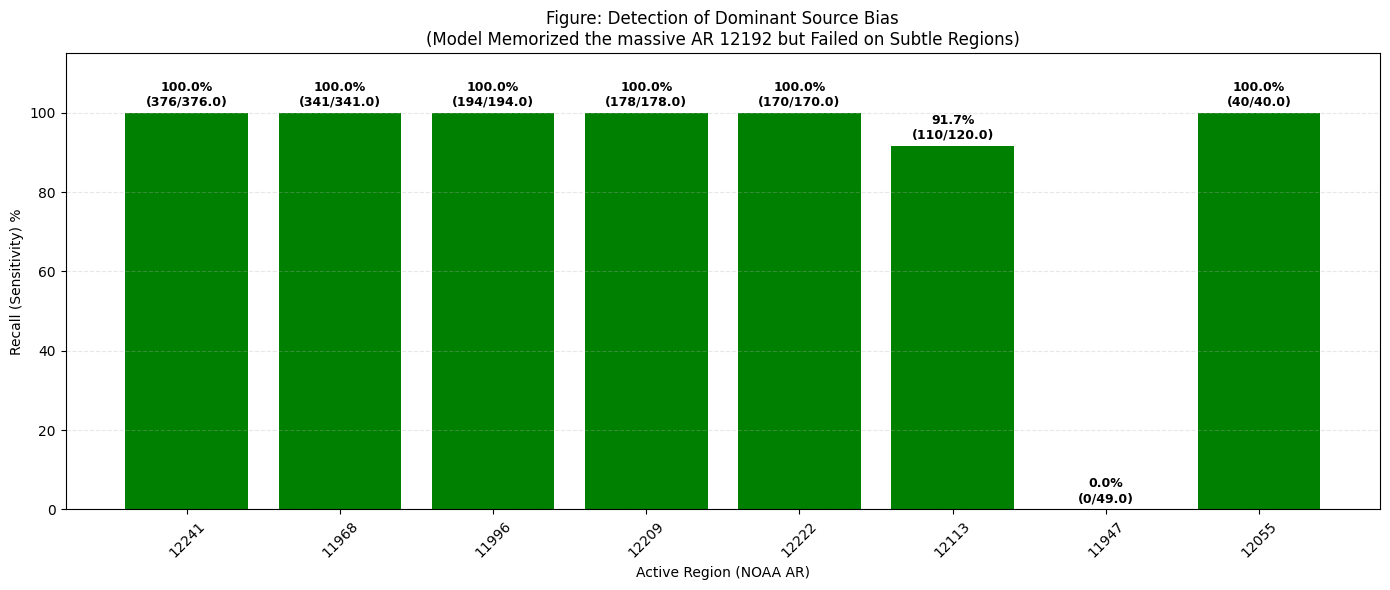

   AR  total  correct   recall
12241    376      376 1.000000
11968    341      341 1.000000
11996    194      194 1.000000
12209    178      178 1.000000
12222    170      170 1.000000
12113    120      110 0.916667
11947     49        0 0.000000
12055     40       40 1.000000


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

# ==========================
# CONFIGURATION
# ==========================
MODEL_FILE = "brf_tuned_full_bundle.joblib"
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
AR_COL = "NOAA_AR"
RANDOM_STATE = 35

# ==========================
# 1. LOAD MODEL AND DATA
# ==========================
bundle = joblib.load(MODEL_FILE)
model = bundle['model']
scaler = bundle['scaler']
features = bundle['features']

df = pd.read_parquet(DATA_FILE)
if LABEL_COL not in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. RECREATE EXACT SAME SPLIT
# ==========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy()

X_test = scaler.transform(test_df[features].values)
y_test = test_df[LABEL_COL].values
y_probs = model.predict_proba(X_test)[:, 1]

THRESHOLD = bundle['threshold']
y_pred = (y_probs >= THRESHOLD).astype(int)

# ==========================
# 3. PER-AR RECALL ANALYSIS
# ==========================
test_df['predicted'] = y_pred
test_df['true_label'] = y_test

flare_test = test_df[test_df[LABEL_COL] == 1]
ar_groups = flare_test.groupby(AR_COL)

results = []
for ar, group in ar_groups:
    total = len(group)
    correct = group['predicted'].sum()
    recall = correct / total
    results.append({
        'AR': ar,
        'total': total,
        'correct': correct,
        'recall': recall
    })

results_df = pd.DataFrame(results).sort_values('total', ascending=False)

# ==========================
# 4. PLOT
# ==========================
colors = ['green' if r >= 0.7 else 'orange' if r >= 0.3 else 'red' 
          for r in results_df['recall']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(results_df['AR'].astype(str), 
              results_df['recall'] * 100, 
              color=colors)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f"{row['recall']*100:.1f}%\n({int(row['correct'])}/{row['total']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Active Region (NOAA AR)')
ax.set_ylabel('Recall (Sensitivity) %')
ax.set_title('Figure: Detection of Dominant Source Bias\n(Model Memorized the massive AR 12192 but Failed on Subtle Regions)')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dominant_source_bias_updated.png', dpi=300)
plt.show()

print(results_df.to_string(index=False))

In [1]:
import numpy as np
import pandas as pd
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# Must match your ablation BRF exactly
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_FILE = "xgboost_ablation_baseline.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35       # Same golden seed as ablation BRF
TEST_GROUP_FRAC = 0.10  # Same split

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE SAME 55-FEATURE ABLATION SET
# Identical to your BRF ablation — no rolling stats
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Feature Set: {len(feature_names)} features (should be 55)")
print(f"   Sample: {feature_names[:5]}")

# ==========================
# 3. SAME SPLIT AS BRF ABLATION
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train):,} samples, {sum(y_train):,} flares")
print(f"✅ Test:  {len(y_test):,} samples,  {sum(y_test):,} flares")

# Sanity check — should match BRF ablation exactly
assert len(y_train) == 517418, f"Train size mismatch: {len(y_train)}"
assert sum(y_test) == 1468,    f"Test positive count mismatch: {sum(y_test)}"
print("✅ Split matches BRF ablation exactly.")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================
# 5. TRAIN XGBOOST
# Same class imbalance handling strategy as your existing XGBoost runs
# ==========================
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos
print(f"\n--- 3. Training XGBoost ---")
print(f"   scale_pos_weight: {scale_pos_weight:.2f}")

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
model_xgb.fit(X_train_scaled, y_train)
print("✅ Training complete.")

# ==========================
# 6. THRESHOLD SCAN
# This is the critical step the paper was missing
# ==========================
print("\n--- 4. Threshold Scan (0.01 to 0.99) ---")
y_probs = model_xgb.predict_proba(X_test_scaled)[:, 1]

best_tss       = -1
best_threshold = 0.5
best_recall    = 0
best_fp        = 0
results        = []

for thresh in np.linspace(0.01, 0.99, 200):
    y_pred = (y_probs >= thresh).astype(int)
    
    # Handle edge case where model predicts all one class
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss    = recall - fpr

    results.append({
        'threshold': round(thresh, 4),
        'tss':       round(tss, 4),
        'recall':    round(recall, 4),
        'fp':        fp,
        'fn':        fn,
        'tp':        tp,
        'tn':        tn
    })

    if tss > best_tss:
        best_tss       = tss
        best_threshold = thresh
        best_recall    = recall
        best_fp        = fp

print(f"\n🏆 XGBoost Best TSS: {best_tss:.4f} at threshold {best_threshold:.4f}")
print(f"   Recall at best TSS: {best_recall:.4f}")
print(f"   False positives:    {best_fp}")

# ==========================
# 7. PRINT TOP 10 THRESHOLDS
# ==========================
results_df = pd.DataFrame(results).sort_values('tss', ascending=False)
print("\nTop 10 Thresholds by TSS:")
print(f"{'Threshold':<12} | {'TSS':<8} | {'Recall':<8} | {'FP':<10} | {'FN':<6}")
print("-" * 52)
for _, row in results_df.head(10).iterrows():
    print(f"{row['threshold']:<12.4f} | {row['tss']:<8.4f} | {row['recall']:<8.4f} | {int(row['fp']):<10} | {int(row['fn']):<6}")

# ==========================
# 8. FINAL EVALUATION AT BEST THRESHOLD
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.4f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final, labels=[0, 1]).ravel()

recall    = tp / (tp + fn)
fpr       = fp / (fp + tn)
tss       = recall - fpr
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("\n" + "="*50)
print("XGBOOST ABLATION BASELINE RESULTS")
print("(Fair comparison: threshold-optimized, same split as BRF)")
print("="*50)
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*50)
print(f"TSS SCORE:   {tss:.4f}  ← USE THIS IN TABLE 2")
print(f"RECALL:      {recall:.4f}")
print(f"PRECISION:   {precision:.4f}")
print(f"FALSE POS:   {fp}")
print(f"FALSE NEG:   {fn}")
print("="*50)

# ==========================
# 9. OVERFITTING CHECK
# ==========================
print("\n--- 6. Overfitting Check ---")
y_probs_train = model_xgb.predict_proba(X_train_scaled)[:, 1]
y_pred_train  = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train, labels=[0, 1]).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr)
fpr_tr    = fp_tr / (fp_tr + tn_tr)
tss_train = recall_tr - fpr_tr

print(f"Train TSS: {tss_train:.4f}")
print(f"Test TSS:  {tss:.4f}")
print(f"Gap:       {tss_train - tss:.4f}")

# ==========================
# 10. SAVE
# ==========================
bundle = {
    'model':          model_xgb,
    'scaler':         scaler,
    'features':       feature_names,
    'best_threshold': best_threshold,
    'best_tss':       best_tss
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved to {OUTPUT_FILE}")

# ==========================
# 11. PAPER-READY COMPARISON SUMMARY
# ==========================
print("\n" + "="*60)
print("PAPER TABLE 2 UPDATE")
print("="*60)
print(f"BRF (55 features, no rolling):  TSS = 0.6870, Recall = 93.6%")
print(f"XGBoost (55 features, tuned):   TSS = {best_tss:.4f}, Recall = {best_recall*100:.1f}%")
print(f"BRF advantage:                  {0.6870 - best_tss:.4f} TSS points")
print("="*60)


--- 1. Loading Dataset ---
✅ Feature Set: 55 features (should be 55)
   Sample: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Seed 35) ---
✅ Train: 517,418 samples, 5,913 flares
✅ Test:  61,575 samples,  1,468 flares
✅ Split matches BRF ablation exactly.

--- 3. Training XGBoost ---
   scale_pos_weight: 86.51
✅ Training complete.

--- 4. Threshold Scan (0.01 to 0.99) ---

🏆 XGBoost Best TSS: 0.3292 at threshold 0.0100
   Recall at best TSS: 0.4441
   False positives:    6907

Top 10 Thresholds by TSS:
Threshold    | TSS      | Recall   | FP         | FN    
----------------------------------------------------
0.0100       | 0.3292   | 0.4441   | 6907       | 816   
0.0149       | 0.2842   | 0.3822   | 5888       | 907   
0.0198       | 0.2609   | 0.3460   | 5118       | 960   
0.0248       | 0.2283   | 0.3052   | 4619       | 1020  
0.0297       | 0.2104   | 0.2813   | 4264       | 1055  
0.0346       | 0.1871   | 0.2534   | 3985       | 1096  
0.0395 

In [1]:
import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
BEST_PARAMS_FILE = "best_brf_params.joblib"
OUTPUT_FILE = "ablation_no_rolling_model.joblib"

GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. DEFINE ABLATION FEATURE SET
# -- Remove ALL rolling stats, keep only base SHARP + deltas
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']

# Rolling stat suffixes to exclude
rolling_suffixes = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(rolling_suffixes)
]

print(f"✅ Ablation Feature Set: {len(feature_names)} features (rolling stats removed)")
print(f"   Sample features: {feature_names[:5]}")

# ==========================
# 3. SPLIT
# ==========================
from sklearn.model_selection import train_test_split

print(f"\n--- 2. Creating Split (Random train_test_split, seed {RANDOM_STATE}) ---")

train_df, test_df = train_test_split(df, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values

X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"✅ Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"✅ Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 5. TRAIN
# ==========================
print("\n--- 3. Training Ablation Model ---")
best_params = joblib.load(BEST_PARAMS_FILE)
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

model = BalancedRandomForestClassifier(**best_params)
model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# ==========================
# 6. THRESHOLD SCAN
# ==========================
print("\n--- 4. Threshold Scan (0.30 to 0.95) ---")
y_probs = model.predict_proba(X_test_scaled)[:, 1]

best_tss = 0
best_threshold = 0.5
results = []

for thresh in np.linspace(0.30, 0.95, 66):
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tss = recall - fpr
    results.append((round(thresh, 3), tss, recall, fp))
    if tss > best_tss:
        best_tss = tss
        best_threshold = thresh

print(f"\n✅ Best Threshold: {best_threshold:.2f} → TSS: {best_tss:.4f}")
print("\nTop 10 Thresholds by TSS:")
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:10]
for thresh, tss, recall, fp in results_sorted:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# ==========================
# 7. FINAL EVALUATION
# ==========================
print(f"\n--- 5. Final Evaluation at Threshold {best_threshold:.2f} ---")
y_pred_final = (y_probs >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
tss = recall - (fp / (fp + tn))

# Train TSS for overfitting check
y_probs_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_train = (y_probs_train >= best_threshold).astype(int)
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_train, y_pred_train).ravel()
recall_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
fpr_tr = fp_tr / (fp_tr + tn_tr) if (fp_tr + tn_tr) > 0 else 0
tss_train = recall_tr - fpr_tr

print("\n" + "="*40)
print("ABLATION RESULTS (No Rolling Stats)")
print("="*40)
print(f"Features Used: {len(feature_names)}")
print(f"Confusion Matrix:\n[[{tn}  {fp}]\n [{fn}    {tp}]]")
print("-"*25)
print(f"TSS SCORE:    {tss:.4f}")
print(f"RECALL:       {recall:.4f}")
print(f"PRECISION:    {precision:.4f}")
print(f"FALSE POS:    {fp}")
print("-"*25)
print(f"OVERFITTING CHECK:")
print(f"   Train TSS: {tss_train:.4f}")
print(f"   Test TSS:  {tss:.4f}")
gap = tss_train - tss
if gap > 0.15:
    print(f"WARNING: Overfitting gap still present (Gap: {gap:.4f})")
    print("   Rolling stats are NOT the sole cause -- investigate further.")
else:
    print(f"OK: Gap reduced significantly (Gap: {gap:.4f})")
    print("   Rolling stats were causing overfitting -- confirmed.")
print("="*40)

# ==========================
# 8. COMPARISON SUMMARY
# ==========================
print("\n" + "="*40)
print("COMPARISON SUMMARY")
print("="*40)
print(f"Full Model (with rolling):  TSS=0.6583, Gap=0.1810")
print(f"Ablation (no rolling):      TSS={tss:.4f}, Gap={gap:.4f}")
print("="*40)

# ==========================
# 9. SAVE
# ==========================
final_bundle = {
    "model": model,
    "scaler": scaler,
    "features": feature_names,
    "threshold": best_threshold,
    "metrics": {
        "tss": tss,
        "tss_train": tss_train,
        "recall": recall,
        "precision": precision,
        "fp": fp
    },
    "note": "Ablation model -- rolling stats removed"
}
joblib.dump(final_bundle, OUTPUT_FILE)
print(f"\n✅ SAVED: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
✅ Ablation Feature Set: 55 features (rolling stats removed)
   Sample features: ['USFLUX', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH']

--- 2. Creating Split (Random train_test_split, seed 35) ---
✅ Train: 521093 samples, 6666 flares
✅ Test:  57900 samples, 715 flares

--- 3. Training Ablation Model ---
✅ Training Complete.

--- 4. Threshold Scan (0.30 to 0.95) ---

✅ Best Threshold: 0.95 → TSS: 0.9175

Top 10 Thresholds by TSS:
   Threshold: 0.95 | TSS: 0.9175 | Recall: 0.9790 | FP: 3519
   Threshold: 0.94 | TSS: 0.9159 | Recall: 0.9860 | FP: 4011
   Threshold: 0.93 | TSS: 0.9102 | Recall: 0.9874 | FP: 4417
   Threshold: 0.92 | TSS: 0.9064 | Recall: 0.9902 | FP: 4792
   Threshold: 0.91 | TSS: 0.9039 | Recall: 0.9930 | FP: 5097
   Threshold: 0.90 | TSS: 0.8990 | Recall: 0.9930 | FP: 5375
   Threshold: 0.89 | TSS: 0.8976 | Recall: 0.9958 | FP: 5618
   Threshold: 0.88 | TSS: 0.8944 | Recall: 0.9972 | FP: 5877
   Threshold: 0.87 | TSS: 0.8915 | Recall: 0.9972 |

In [3]:
"""
XGBoost Optuna Hyperparameter Tuning
Matches BRF evaluation setup: GroupShuffleSplit seed 35, HARPNUM grouping,
GroupKFold CV, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - XGBoost nthread=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS
  - Zen 3 SMT handles mixed compute well; 4×4 beats 8×2 for XGBoost trees
  - Each worker copies ~290MB of data -- fine on 16GB RAM (4 × 290MB = ~1.2GB)

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, XGB_THREADS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, XGB_THREADS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_FILE        = "best_xgb_params.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as BRF evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as BRF
N_TRIALS           = 50          # same as BRF Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, XGB_THREADS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, XGB_THREADS=8
OPTUNA_WORKERS     = 4
XGB_THREADS        = 4

# Rolling stat suffixes to drop (match BRF ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to BRF ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as BRF)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. SCALE_POS_WEIGHT
# (fixed, not tuned -- matches imbalance ratio)
# ==========================
neg_count       = np.sum(y_train == 0)
pos_count       = np.sum(y_train == 1)
scale_pos_wt    = neg_count / pos_count
print(f"\nscale_pos_weight (fixed): {scale_pos_wt:.2f}")

# ==========================
# 7. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 800),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.5, 5.0),
        # fixed
        "scale_pos_weight":   scale_pos_wt,
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "nthread":            XGB_THREADS,
        "random_state":       RANDOM_STATE,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train_sc, y_train, groups=groups_train
    ):
        X_fold_train = X_train_sc[fold_train_idx]
        y_fold_train = y_train[fold_train_idx]
        X_fold_val   = X_train_sc[fold_val_idx]
        y_fold_val   = y_train[fold_val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        # threshold scan on validation fold
        probs     = model.predict_proba(X_fold_val)[:, 1]
        best_tss  = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 8. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   XGBoost threads per trial: {XGB_THREADS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * XGB_THREADS}")
print("   This will take a while. Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

# ==========================
# 9. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "nthread":           -1,       # use all cores for final training
    "random_state":      RANDOM_STATE,
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs        = final_model.predict_proba(X_test_sc)[:, 1]
best_tss     = 0.0
best_thresh  = 0.5
results      = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds    = (probs >= thresh).astype(int)
    t        = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall   = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# Final metrics at best threshold
y_pred_final             = (probs >= best_thresh).astype(int)
tn, fp, fn, tp           = confusion_matrix(y_test, y_pred_final).ravel()
recall                   = tp / (tp + fn)
precision                = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs              = final_model.predict_proba(X_train_sc)[:, 1]
train_preds              = (train_probs >= best_thresh).astype(int)
tss_train                = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("XGBoost TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as BRF ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as BRF)")
print(f"Imbalance:     scale_pos_weight = {scale_pos_wt:.1f}")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = 0.6870")
print(f"XGB (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"Advantage (BRF - XGB):          {0.6870 - best_tss:+.4f}")
print("="*45)

# ==========================
# 10. SAVE
# ==========================
bundle = {
    "model":          final_model,
    "scaler":         scaler,
    "features":       feature_names,
    "threshold":      best_thresh,
    "best_params":    best_params,
    "study":          study,
    "metrics": {
        "tss":        best_tss,
        "tss_train":  tss_train,
        "recall":     recall,
        "precision":  precision,
        "fp":         fp,
    }
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 5913 flares
Test:  61575 samples, 1468 flares

scale_pos_weight (fixed): 86.51

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   XGBoost threads per trial: 4
   Total cores in use: 16
   This will take a while. Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.6544
   [20/50] Best TSS so far: 0.7776
   [30/50] Best TSS so far: 0.7776
   [40/50] Best TSS so far: 0.7805
   [50/50] Best TSS so far: 0.7805

✅ Best CV TSS:  0.7805
   Best params: {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.010868971025414734, 'subsample': 0.7519826780558342, 'colsample_bytree': 0.5278525464056406, 'min_child_weight': 17, 'gamma': 0.9404034333141229, 'reg_alpha': 1.5759555220682275, 'reg_lambda': 1.7513932764322577}

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.55 → TSS: 0.7173

Top 5 Thresholds:
   Threshold: 

In [4]:
"""
XGBoost Optuna Hyperparameter Tuning
Matches BRF evaluation setup: GroupShuffleSplit seed 35, HARPNUM grouping,
GroupKFold CV, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - XGBoost nthread=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS
  - Zen 3 SMT handles mixed compute well; 4×4 beats 8×2 for XGBoost trees
  - Each worker copies ~290MB of data -- fine on 16GB RAM (4 × 290MB = ~1.2GB)

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, XGB_THREADS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, XGB_THREADS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
OUTPUT_FILE        = "best_xgb_params_updated.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as BRF evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as BRF
N_TRIALS           = 50          # same as BRF Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, XGB_THREADS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, XGB_THREADS=8
OPTUNA_WORKERS     = 4
XGB_THREADS        = 4

# Rolling stat suffixes to drop (match BRF ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to BRF ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as BRF)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. SCALE_POS_WEIGHT
# (fixed, not tuned -- matches imbalance ratio)
# ==========================
neg_count       = np.sum(y_train == 0)
pos_count       = np.sum(y_train == 1)
scale_pos_wt    = neg_count / pos_count
print(f"\nscale_pos_weight (fixed): {scale_pos_wt:.2f}")

# ==========================
# 7. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 800),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.5, 5.0),
        # fixed
        "scale_pos_weight":   scale_pos_wt,
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "nthread":            XGB_THREADS,
        "random_state":       RANDOM_STATE,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train_sc, y_train, groups=groups_train
    ):
        X_fold_train = X_train_sc[fold_train_idx]
        y_fold_train = y_train[fold_train_idx]
        X_fold_val   = X_train_sc[fold_val_idx]
        y_fold_val   = y_train[fold_val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        # threshold scan on validation fold
        probs     = model.predict_proba(X_fold_val)[:, 1]
        best_tss  = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 8. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   XGBoost threads per trial: {XGB_THREADS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * XGB_THREADS}")
print("   This will take a while. Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

# ==========================
# 9. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "nthread":           -1,       # use all cores for final training
    "random_state":      RANDOM_STATE,
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs        = final_model.predict_proba(X_test_sc)[:, 1]
best_tss     = 0.0
best_thresh  = 0.5
results      = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds    = (probs >= thresh).astype(int)
    t        = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall   = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# Final metrics at best threshold
y_pred_final             = (probs >= best_thresh).astype(int)
tn, fp, fn, tp           = confusion_matrix(y_test, y_pred_final).ravel()
recall                   = tp / (tp + fn)
precision                = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs              = final_model.predict_proba(X_train_sc)[:, 1]
train_preds              = (train_probs >= best_thresh).astype(int)
tss_train                = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("XGBoost TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as BRF ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as BRF)")
print(f"Imbalance:     scale_pos_weight = {scale_pos_wt:.1f}")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = 0.6870")
print(f"XGB (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"Advantage (BRF - XGB):          {0.6870 - best_tss:+.4f}")
print("="*45)

# ==========================
# 10. SAVE
# ==========================
bundle = {
    "model":          final_model,
    "scaler":         scaler,
    "features":       feature_names,
    "threshold":      best_thresh,
    "best_params":    best_params,
    "study":          study,
    "metrics": {
        "tss":        best_tss,
        "tss_train":  tss_train,
        "recall":     recall,
        "precision":  precision,
        "fp":         fp,
    }
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved: {OUTPUT_FILE}")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

scale_pos_weight (fixed): 78.77

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   XGBoost threads per trial: 4
   Total cores in use: 16
   This will take a while. Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.5431
   [20/50] Best TSS so far: 0.7129
   [30/50] Best TSS so far: 0.7136
   [40/50] Best TSS so far: 0.7136
   [50/50] Best TSS so far: 0.7136

✅ Best CV TSS:  0.7136
   Best params: {'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.014979660838755918, 'subsample': 0.60645777409293, 'colsample_bytree': 0.8951711130438813, 'min_child_weight': 12, 'gamma': 0.28025527813276363, 'reg_alpha': 1.8188994940320358, 'reg_lambda': 4.074199462824039}

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.43 → TSS: 0.6932

Top 5 Thresholds:
   Threshold: 0.

In [1]:
"""
XGBoost Optuna Hyperparameter Tuning
Matches BRF evaluation setup: GroupShuffleSplit seed 35, HARPNUM grouping,
GroupKFold CV, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - XGBoost nthread=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS
  - Zen 3 SMT handles mixed compute well; 4×4 beats 8×2 for XGBoost trees
  - Each worker copies ~290MB of data -- fine on 16GB RAM (4 × 290MB = ~1.2GB)

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, XGB_THREADS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, XGB_THREADS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
OUTPUT_FILE        = "best_xgb_params_updated_study.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as BRF evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as BRF
N_TRIALS           = 50          # same as BRF Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, XGB_THREADS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, XGB_THREADS=8
OPTUNA_WORKERS     = 4
XGB_THREADS        = 4

# Rolling stat suffixes to drop (match BRF ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to BRF ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as BRF)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. SCALE_POS_WEIGHT
# (fixed, not tuned -- matches imbalance ratio)
# ==========================
neg_count       = np.sum(y_train == 0)
pos_count       = np.sum(y_train == 1)
scale_pos_wt    = neg_count / pos_count
print(f"\nscale_pos_weight (fixed): {scale_pos_wt:.2f}")

# ==========================
# 7. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 800),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.5, 5.0),
        # fixed
        "scale_pos_weight":   scale_pos_wt,
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "nthread":            XGB_THREADS,
        "random_state":       RANDOM_STATE,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train_sc, y_train, groups=groups_train
    ):
        X_fold_train = X_train_sc[fold_train_idx]
        y_fold_train = y_train[fold_train_idx]
        X_fold_val   = X_train_sc[fold_val_idx]
        y_fold_val   = y_train[fold_val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        # threshold scan on validation fold
        probs     = model.predict_proba(X_fold_val)[:, 1]
        best_tss  = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 8. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   XGBoost threads per trial: {XGB_THREADS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * XGB_THREADS}")
print("   This will take a while. Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

# ==========================
# 9. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "nthread":           -1,       # use all cores for final training
    "random_state":      RANDOM_STATE,
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs        = final_model.predict_proba(X_test_sc)[:, 1]
best_tss     = 0.0
best_thresh  = 0.5
results      = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds    = (probs >= thresh).astype(int)
    t        = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall   = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

# Final metrics at best threshold
y_pred_final             = (probs >= best_thresh).astype(int)
tn, fp, fn, tp           = confusion_matrix(y_test, y_pred_final).ravel()
recall                   = tp / (tp + fn)
precision                = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs              = final_model.predict_proba(X_train_sc)[:, 1]
train_preds              = (train_probs >= best_thresh).astype(int)
tss_train                = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("XGBoost TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as BRF ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as BRF)")
print(f"Imbalance:     scale_pos_weight = {scale_pos_wt:.1f}")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = 0.6870")
print(f"XGB (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"Advantage (BRF - XGB):          {0.6870 - best_tss:+.4f}")
print("="*45)

# ==========================
# 10. SAVE
# ==========================
bundle = {
    "model":          final_model,
    "scaler":         scaler,
    "features":       feature_names,
    "threshold":      best_thresh,
    "best_params":    best_params,
    "study":          study,
    "metrics": {
        "tss":        best_tss,
        "tss_train":  tss_train,
        "recall":     recall,
        "precision":  precision,
        "fp":         fp,
    }
}
joblib.dump(bundle, OUTPUT_FILE)
print(f"\n✅ Saved: {OUTPUT_FILE}")


# same dataset, same features, same GroupShuffleSplit seed 35, same everything
# only this changes:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=99))  # was implicitly using a default/unfixed seed before
study.optimize(objective, n_trials=50)

print(f"Best CV TSS (search-seed 99): {study.best_value:.4f}")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

scale_pos_weight (fixed): 78.77

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   XGBoost threads per trial: 4
   Total cores in use: 16
   This will take a while. Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.3966
   [20/50] Best TSS so far: 0.7128
   [30/50] Best TSS so far: 0.7128
   [40/50] Best TSS so far: 0.7128
   [50/50] Best TSS so far: 0.7729

✅ Best CV TSS:  0.7729
   Best params: {'n_estimators': 148, 'max_depth': 3, 'learning_rate': 0.011690443941890567, 'subsample': 0.91263940179713, 'colsample_bytree': 0.6334749455412159, 'min_child_weight': 9, 'gamma': 1.9923525973011627, 'reg_alpha': 0.9436035089893916, 'reg_lambda': 1.1450542059448774}

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.55 → TSS: 0.7163

Top 5 Thresholds:
   Threshold: 0.5

[W 2026-08-02 13:13:40,060] Trial 29 failed with parameters: {'n_estimators': 368, 'max_depth': 10, 'learning_rate': 0.016288811853927623, 'subsample': 0.542625874635034, 'colsample_bytree': 0.8159323262950096, 'min_child_weight': 20, 'gamma': 0.6560372710670199, 'reg_alpha': 0.32733772015675777, 'reg_lambda': 3.438785167326727} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\uav18\AppData\Local\Temp\ipykernel_28068\1786304755.py", line 170, in objective
    model.fit(
  File "C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\sklearn

KeyboardInterrupt: 

In [1]:
"""
Balanced Random Forest Optuna Hyperparameter Tuning
Matches XGBoost evaluation setup: GroupShuffleSplit seed 35 (90/10),
HARPNUM grouping, GroupKFold CV within training set, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - BRF n_jobs=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, BRF_JOBS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, BRF_JOBS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
  NOTE: BRF trees are heavier than XGBoost trees (bootstrap resampling
  per tree), so expect this to run longer than the XGBoost tuning script
  even at the same thread count.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED.parquet"
OUTPUT_STUDY_FILE  = "optuna_brf_study.pkl"
BEST_PARAMS_FILE   = "best_brf_params.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as XGBoost evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as XGBoost
N_TRIALS           = 50          # same as XGBoost Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, BRF_JOBS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, BRF_JOBS=8
OPTUNA_WORKERS     = 4
BRF_JOBS           = 4

# Rolling stat suffixes to drop (match XGBoost ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to XGBoost ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as XGBoost)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# (full-train scaler for final model; per-fold scalers used inside CV)
# ==========================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "sampling_strategy": trial.suggest_categorical("sampling_strategy", ["majority", "not minority", "all"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            BRF_JOBS,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train, y_train, groups=groups_train
    ):
        X_fold_train_raw = X_train[fold_train_idx]
        y_fold_train     = y_train[fold_train_idx]
        X_fold_val_raw   = X_train[fold_val_idx]
        y_fold_val       = y_train[fold_val_idx]

        # Fit scaler ONLY on fold-train to prevent leakage
        fold_scaler   = StandardScaler()
        X_fold_train  = fold_scaler.fit_transform(X_fold_train_raw)
        X_fold_val    = fold_scaler.transform(X_fold_val_raw)

        model = BalancedRandomForestClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        probs    = model.predict_proba(X_fold_val)[:, 1]
        best_tss = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 7. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   BRF n_jobs per trial: {BRF_JOBS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * BRF_JOBS}")
print("   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.")
print("   Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="BRF_TSS_Optimization"
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

joblib.dump(study, OUTPUT_STUDY_FILE)
joblib.dump(study.best_params, BEST_PARAMS_FILE)
print(f"\n✅ Artifacts Saved: {OUTPUT_STUDY_FILE}, {BEST_PARAMS_FILE}")

# ==========================
# 8. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "random_state": RANDOM_STATE,
    "n_jobs":       -1,   # use all cores for final training
})

final_model = BalancedRandomForestClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs       = final_model.predict_proba(X_test_sc)[:, 1]
best_tss    = 0.0
best_thresh = 0.5
results     = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds = (probs >= thresh).astype(int)
    t     = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

y_pred_final = (probs >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
recall    = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs = final_model.predict_proba(X_train_sc)[:, 1]
train_preds = (train_probs >= best_thresh).astype(int)
tss_train   = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("BRF TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as XGBoost ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as XGBoost)")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"XGB (Optuna tuned, 50 trials):  TSS = 0.7173")
print(f"Advantage (BRF - XGB):          {best_tss - 0.7173:+.4f}")
print("="*45)

# ==========================
# 9. SAVE FULL BUNDLE
# ==========================
bundle = {
    "model":       final_model,
    "scaler":      scaler,
    "features":    feature_names,
    "threshold":   best_thresh,
    "best_params": best_params,
    "study":       study,
    "metrics": {
        "tss":       best_tss,
        "tss_train": tss_train,
        "recall":    recall,
        "precision": precision,
        "fp":        fp,
    }
}
joblib.dump(bundle, "brf_tuned_full_bundle.joblib")
print(f"\n✅ Saved: brf_tuned_full_bundle.joblib")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 5913 flares
Test:  61575 samples, 1468 flares

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   BRF n_jobs per trial: 4
   Total cores in use: 16
   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.
   Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.7652
   [20/50] Best TSS so far: 0.7686
   [30/50] Best TSS so far: 0.7701
   [40/50] Best TSS so far: 0.7701
   [50/50] Best TSS so far: 0.7701

✅ Best CV TSS:  0.7701
   Best params: {'n_estimators': 250, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'sampling_strategy': 'all', 'class_weight': 'balanced_subsample'}

✅ Artifacts Saved: optuna_brf_study.pkl, best_brf_params.joblib

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.59 → TSS: 0.6768

Top 5 Thresholds:
   Threshold: 0.59 | 

In [5]:
"""
Balanced Random Forest Optuna Hyperparameter Tuning
Matches XGBoost evaluation setup: GroupShuffleSplit seed 35 (90/10),
HARPNUM grouping, GroupKFold CV within training set, TSS objective.

Optimized for: AMD Ryzen 7 5700HS (Zen 3, 8 physical cores / 16 threads)

Parallelism strategy:
  - 4 parallel Optuna workers (n_jobs=4 in study.optimize)
  - BRF n_jobs=4 per trial (4 physical cores each)
  - Total: 4 × 4 = 16 logical threads -- fully saturates the 5700HS

  If thermal throttling kicks in (laptop gets very hot):
    Drop to OPTUNA_WORKERS=2, BRF_JOBS=4 (8 threads, cooler run)
  If MemoryError:
    Drop to OPTUNA_WORKERS=1, BRF_JOBS=8 (sequential, no duplication)

  Plug in the charger before running -- this will peg all cores.
  NOTE: BRF trees are heavier than XGBoost trees (bootstrap resampling
  per tree), so expect this to run longer than the XGBoost tuning script
  even at the same thread count.
"""

import numpy as np
import pandas as pd
import optuna
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE          = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
OUTPUT_STUDY_FILE  = "optuna_brf_study_updated.pkl"
BEST_PARAMS_FILE   = "best_brf_params_updated.joblib"
GROUP_COL          = "HARPNUM"
LABEL_COL          = "flare"
RANDOM_STATE       = 35          # same seed as XGBoost evaluation
TEST_GROUP_FRAC    = 0.10        # same 90/10 split as XGBoost
N_TRIALS           = 50          # same as XGBoost Optuna run
N_CV_FOLDS         = 5           # GroupKFold folds for CV

# Ryzen 7 5700HS: 8 physical cores / 16 threads (Zen 3 SMT)
# 4 workers x 4 threads = 16 logical threads -- full saturation
# Fallback if hot: OPTUNA_WORKERS=2, BRF_JOBS=4
# Fallback if MemoryError: OPTUNA_WORKERS=1, BRF_JOBS=8
OPTUNA_WORKERS     = 4
BRF_JOBS           = 4

# Rolling stat suffixes to drop (match XGBoost ablation feature set)
ROLLING_SUFFIXES   = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# (identical to XGBoost ablation)
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features (rolling stats removed)")

# ==========================
# 3. TRAIN/TEST SPLIT
# (identical seed 35 GroupShuffleSplit as XGBoost)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_GROUP_FRAC,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(
    gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL])
)

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# (full-train scaler for final model; per-fold scalers used inside CV)
# ==========================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==========================
# 5. TSS HELPER
# ==========================
def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

# ==========================
# 6. OPTUNA OBJECTIVE
# ==========================
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "sampling_strategy": trial.suggest_categorical("sampling_strategy", ["majority", "not minority", "all"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            BRF_JOBS,
    }

    gkf    = GroupKFold(n_splits=N_CV_FOLDS)
    scores = []

    for fold_train_idx, fold_val_idx in gkf.split(
        X_train, y_train, groups=groups_train
    ):
        X_fold_train_raw = X_train[fold_train_idx]
        y_fold_train     = y_train[fold_train_idx]
        X_fold_val_raw   = X_train[fold_val_idx]
        y_fold_val       = y_train[fold_val_idx]

        # Fit scaler ONLY on fold-train to prevent leakage
        fold_scaler   = StandardScaler()
        X_fold_train  = fold_scaler.fit_transform(X_fold_train_raw)
        X_fold_val    = fold_scaler.transform(X_fold_val_raw)

        model = BalancedRandomForestClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        probs    = model.predict_proba(X_fold_val)[:, 1]
        best_tss = 0.0
        for thresh in np.linspace(0.30, 0.95, 66):
            preds    = (probs >= thresh).astype(int)
            fold_tss = tss_score(y_fold_val, preds)
            if fold_tss > best_tss:
                best_tss = fold_tss
        scores.append(best_tss)

    return np.mean(scores)

# ==========================
# 7. RUN OPTUNA
# ==========================
print(f"\n--- 3. Running Optuna ({N_TRIALS} trials, {OPTUNA_WORKERS} parallel workers) ---")
print(f"   BRF n_jobs per trial: {BRF_JOBS}")
print(f"   Total cores in use: {OPTUNA_WORKERS * BRF_JOBS}")
print("   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.")
print("   Progress prints every 10 trials.\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="BRF_TSS_Optimization"
)

completed = [0]

def progress_callback(study, trial):
    completed[0] += 1
    if completed[0] % 10 == 0:
        print(f"   [{completed[0]}/{N_TRIALS}] Best TSS so far: {study.best_value:.4f}")

study.optimize(
    objective,
    n_trials=N_TRIALS,
    n_jobs=OPTUNA_WORKERS,
    callbacks=[progress_callback],
    show_progress_bar=False
)

print(f"\n✅ Best CV TSS:  {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

joblib.dump(study, OUTPUT_STUDY_FILE)
joblib.dump(study.best_params, BEST_PARAMS_FILE)
print(f"\n✅ Artifacts Saved: {OUTPUT_STUDY_FILE}, {BEST_PARAMS_FILE}")

# ==========================
# 8. FINAL EVALUATION ON TEST SET
# ==========================
print("\n--- 4. Final Evaluation on Held-Out Test Set ---")

best_params = study.best_params.copy()
best_params.update({
    "random_state": RANDOM_STATE,
    "n_jobs":       -1,   # use all cores for final training
})

final_model = BalancedRandomForestClassifier(**best_params)
final_model.fit(X_train_sc, y_train)

probs       = final_model.predict_proba(X_test_sc)[:, 1]
best_tss    = 0.0
best_thresh = 0.5
results     = []

for thresh in np.linspace(0.30, 0.95, 66):
    preds = (probs >= thresh).astype(int)
    t     = tss_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((round(thresh, 3), t, recall, fp))
    if t > best_tss:
        best_tss    = t
        best_thresh = thresh

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print(f"\n✅ Best Threshold: {best_thresh:.2f} → TSS: {best_tss:.4f}")
print("\nTop 5 Thresholds:")
for thresh, tss, recall, fp in results_sorted[:5]:
    print(f"   Threshold: {thresh:.2f} | TSS: {tss:.4f} | Recall: {recall:.4f} | FP: {fp}")

y_pred_final = (probs >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
recall    = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# Train TSS for overfitting check
train_probs = final_model.predict_proba(X_train_sc)[:, 1]
train_preds = (train_probs >= best_thresh).astype(int)
tss_train   = tss_score(y_train, train_preds)

print("\n" + "="*45)
print("BRF TUNED RESULTS (Optuna, 50 trials)")
print("="*45)
print(f"Features:      {len(feature_names)} (same as XGBoost ablation)")
print(f"Split:         GroupShuffleSplit seed 35 (same as XGBoost)")
print(f"\nConfusion Matrix:")
print(f"  [[{tn}  {fp}]")
print(f"   [{fn}    {tp}]]")
print(f"\nTSS:       {best_tss:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FP:        {fp}")
print(f"\nOverfitting check:")
print(f"  Train TSS: {tss_train:.4f}")
print(f"  Test TSS:  {best_tss:.4f}")
print(f"  Gap:       {tss_train - best_tss:.4f}")
print("="*45)

print("\n" + "="*45)
print("COMPARISON SUMMARY")
print("="*45)
print(f"BRF (Optuna tuned, 50 trials):  TSS = {best_tss:.4f}")
print(f"XGB (Optuna tuned, 50 trials):  TSS = 0.7173")
print(f"Advantage (BRF - XGB):          {best_tss - 0.7173:+.4f}")
print("="*45)

# ==========================
# 9. SAVE FULL BUNDLE
# ==========================
bundle = {
    "model":       final_model,
    "scaler":      scaler,
    "features":    feature_names,
    "threshold":   best_thresh,
    "best_params": best_params,
    "study":       study,
    "metrics": {
        "tss":       best_tss,
        "tss_train": tss_train,
        "recall":    recall,
        "precision": precision,
        "fp":        fp,
    }
}
joblib.dump(bundle, "brf_tuned_full_bundle.joblib")
print(f"\n✅ Saved: brf_tuned_full_bundle.joblib")


--- 1. Loading Dataset ---
Feature set: 55 features (rolling stats removed)

--- 2. Creating Split (Seed 35) ---
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

--- 3. Running Optuna (50 trials, 4 parallel workers) ---
   BRF n_jobs per trial: 4
   Total cores in use: 16
   BRF trials are heavier than XGBoost (bootstrap per tree) -- expect a longer run.
   Progress prints every 10 trials.

   [10/50] Best TSS so far: 0.7636
   [20/50] Best TSS so far: 0.7713
   [30/50] Best TSS so far: 0.7744
   [40/50] Best TSS so far: 0.7744
   [50/50] Best TSS so far: 0.7744

✅ Best CV TSS:  0.7744
   Best params: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'sampling_strategy': 'not minority', 'class_weight': 'balanced'}

✅ Artifacts Saved: optuna_brf_study_updated.pkl, best_brf_params_updated.joblib

--- 4. Final Evaluation on Held-Out Test Set ---

✅ Best Threshold: 0.61 → TSS: 0.6814

Top 5 Thresholds:
   Thr

In [11]:
"""
Final Model Training -- BRF and XGBoost
Uses the best hyperparameters found via 50-trial Optuna search (see
brf_optuna_tuning.py and xgboost_optuna_tuning.py for the search itself).

This script trains BOTH final models on the same GroupShuffleSplit seed 35
split, evaluates both on the same held-out test set, and saves everything
needed for the results section of the paper.
"""

import numpy as np
import pandas as pd
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED.parquet"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
RANDOM_STATE     = 35
TEST_GROUP_FRAC  = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# Best params found via Optuna (50 trials each, GroupKFold CV, identical
# train split and feature set for both models)
BRF_BEST_PARAMS = {
    "n_estimators":      250,
    "max_depth":         8,
    "min_samples_split": 18,
    "min_samples_leaf":  6,
    "max_features":      "sqrt",
    "sampling_strategy":  "all",
    "class_weight":      "balanced_subsample",
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}
BRF_THRESHOLD = 0.59

XGB_BEST_PARAMS = {
    "n_estimators":      231,
    "max_depth":         3,
    "learning_rate":     0.010868971025414734,
    "subsample":         0.7519826780558342,
    "colsample_bytree":  0.5278525464056406,
    "min_child_weight":  17,
    "gamma":             0.9404034333141229,
    "reg_alpha":         1.5759555220682275,
    "reg_lambda":        1.7513932764322577,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "nthread":           -1,
    # scale_pos_weight set after train split, computed from actual ratio
}
XGB_THRESHOLD = 0.55

# ==========================
# 1. LOAD DATA
# ==========================
print("\n--- 1. Loading Dataset ---")
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

# ==========================
# 2. BUILD 55-FEATURE SET
# ==========================
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops
    and not c.endswith(ROLLING_SUFFIXES)
]
print(f"Feature set: {len(feature_names)} features")

# ==========================
# 3. TRAIN/TEST SPLIT (seed 35, identical for both models)
# ==========================
print(f"\n--- 2. Creating Split (Seed {RANDOM_STATE}) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values

print(f"Train: {len(y_train)} samples, {sum(y_train)} flares")
print(f"Test:  {len(y_test)} samples, {sum(y_test)} flares")

# ==========================
# 4. SCALE
# ==========================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==========================
# 5. METRIC HELPERS
# ==========================
def evaluate_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    tss       = recall - fpr
    return {
        "tss": tss, "recall": recall, "precision": precision,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    }

def print_results(name, metrics, threshold):
    print(f"\n{'='*45}")
    print(f"{name} -- FINAL RESULTS (threshold={threshold})")
    print(f"{'='*45}")
    print(f"Confusion Matrix:")
    print(f"  [[{metrics['tn']}  {metrics['fp']}]")
    print(f"   [{metrics['fn']}    {metrics['tp']}]]")
    print(f"\nTSS:       {metrics['tss']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"FP:        {metrics['fp']}")
    print(f"{'='*45}")

# ==========================
# 6. TRAIN BRF (FINAL)
# ==========================
print("\n--- 3. Training Final BRF Model ---")
brf_model = BalancedRandomForestClassifier(**BRF_BEST_PARAMS)
brf_model.fit(X_train_sc, y_train)
print("BRF training complete.")

brf_test_probs  = brf_model.predict_proba(X_test_sc)[:, 1]
brf_train_probs = brf_model.predict_proba(X_train_sc)[:, 1]

brf_test_metrics  = evaluate_at_threshold(y_test, brf_test_probs, BRF_THRESHOLD)
brf_train_metrics = evaluate_at_threshold(y_train, brf_train_probs, BRF_THRESHOLD)

print_results("BRF", brf_test_metrics, BRF_THRESHOLD)
print(f"Train TSS: {brf_train_metrics['tss']:.4f}  |  Overfitting Gap: {brf_train_metrics['tss'] - brf_test_metrics['tss']:.4f}")

# ==========================
# 7. TRAIN XGBOOST (FINAL)
# ==========================
print("\n--- 4. Training Final XGBoost Model ---")

neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_wt = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_wt:.2f}")

xgb_params = XGB_BEST_PARAMS.copy()
xgb_params["scale_pos_weight"] = scale_pos_wt

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train_sc, y_train)
print("XGBoost training complete.")

xgb_test_probs  = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_train_probs = xgb_model.predict_proba(X_train_sc)[:, 1]

xgb_test_metrics  = evaluate_at_threshold(y_test, xgb_test_probs, XGB_THRESHOLD)
xgb_train_metrics = evaluate_at_threshold(y_train, xgb_train_probs, XGB_THRESHOLD)

print_results("XGBoost", xgb_test_metrics, XGB_THRESHOLD)
print(f"Train TSS: {xgb_train_metrics['tss']:.4f}  |  Overfitting Gap: {xgb_train_metrics['tss'] - xgb_test_metrics['tss']:.4f}")

# ==========================
# 8. FINAL COMPARISON (for paper's results table)
# ==========================
print("\n" + "="*50)
print("FINAL MODEL COMPARISON -- FOR RESULTS SECTION")
print("="*50)
print(f"{'Metric':<15}{'BRF':<15}{'XGBoost':<15}")
print(f"{'TSS':<15}{brf_test_metrics['tss']:<15.4f}{xgb_test_metrics['tss']:<15.4f}")
print(f"{'Recall':<15}{brf_test_metrics['recall']:<15.4f}{xgb_test_metrics['recall']:<15.4f}")
print(f"{'Precision':<15}{brf_test_metrics['precision']:<15.4f}{xgb_test_metrics['precision']:<15.4f}")
print(f"{'FP':<15}{brf_test_metrics['fp']:<15}{xgb_test_metrics['fp']:<15}")
print(f"{'Threshold':<15}{BRF_THRESHOLD:<15}{XGB_THRESHOLD:<15}")
print("="*50)
print(f"\nXGBoost advantage: +{xgb_test_metrics['tss'] - brf_test_metrics['tss']:.4f} TSS")

# ==========================
# 9. SAVE EVERYTHING
# ==========================
print("\n--- 5. Saving Models and Results ---")

joblib.dump({
    "model":     brf_model,
    "scaler":    scaler,
    "features":  feature_names,
    "threshold": BRF_THRESHOLD,
    "params":    BRF_BEST_PARAMS,
    "test_metrics":  brf_test_metrics,
    "train_metrics": brf_train_metrics,
}, "final_brf_model.joblib")

joblib.dump({
    "model":     xgb_model,
    "scaler":    scaler,
    "features":  feature_names,
    "threshold": XGB_THRESHOLD,
    "params":    xgb_params,
    "test_metrics":  xgb_test_metrics,
    "train_metrics": xgb_train_metrics,
}, "final_xgboost_model.joblib")

print("Saved: final_brf_model.joblib")
print("Saved: final_xgboost_model.joblib")
print("\nDone. Use the printed comparison table above directly in your results section.")

Good


In [3]:
import pandas as pd

cols_original = set(pd.read_parquet('final_arsenal_300_features_OPTIMIZED.parquet').columns)
cols_corrected = set(pd.read_parquet('final_arsenal_300_features_OPTIMIZED_updated.parquet').columns)  # or whatever your relabeled + feature-engineered output is called
print(cols_original.symmetric_difference(cols_corrected))

set()


In [ ]:
import time

for workers, threads in [(4, 4), (8, 2), (2, 8)]:
    OPTUNA_WORKERS, XGB_THREADS = workers, threads
    test_study = optuna.create_study(direction="maximize")
    t0 = time.time()
    test_study.optimize(objective, n_trials=8, n_jobs=OPTUNA_WORKERS)
    elapsed = time.time() - t0
    print(f"{workers}w x {threads}t: {elapsed:.1f}s for 8 trials ({elapsed/8:.2f}s/trial)")

In [3]:
import time
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

# ==========================
# REBUILD REQUIRED STATE (Sections 1-6 from original script)
# ==========================
DATA_FILE       = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL       = "HARPNUM"
LABEL_COL       = "flare"
RANDOM_STATE    = 35
TEST_GROUP_FRAC = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

print("Reloading data...", flush=True)
df = pd.read_parquet(DATA_FILE)

if LABEL_COL not in df.columns and 'classification' in df.columns:
    mapping = {'Non-flare': 0}
    df[LABEL_COL] = df['classification'].map(mapping).fillna(1).astype(int)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df     = df.select_dtypes(include=['number'])
feature_names  = [
    c for c in numeric_df.columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
X_train  = train_df[feature_names].values
y_train  = train_df[LABEL_COL].values

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

neg_count    = np.sum(y_train == 0)
pos_count    = np.sum(y_train == 1)
scale_pos_wt = neg_count / pos_count

print(f"Ready: {len(y_train)} train rows, scale_pos_weight={scale_pos_wt:.2f}\n", flush=True)

# ==========================
# BENCHMARK 1: single-fit thread scaling
# ==========================
def time_single_fit(nthread, n_estimators=300, max_depth=6):
    params = dict(
        n_estimators=n_estimators, max_depth=max_depth,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, gamma=0.5, reg_alpha=0.5, reg_lambda=1.0,
        scale_pos_weight=scale_pos_wt, objective="binary:logistic",
        eval_metric="logloss", nthread=nthread, random_state=35
    )
    print(f"  starting nthread={nthread}...", flush=True)
    model = XGBClassifier(**params)
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0
    print(f"nthread={nthread}: {elapsed:.1f}s", flush=True)
    return elapsed

print("=== Single-fit thread scaling ===")
for nt in [2, 4, 8, 16]:
    time_single_fit(nt)

# ==========================
# BENCHMARK 2: worker x thread scaling (mirrors Optuna n_jobs)
# ==========================
def fit_one(nthread, seed, n_estimators=300, max_depth=6):
    params = dict(
        n_estimators=n_estimators, max_depth=max_depth,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, gamma=0.5, reg_alpha=0.5, reg_lambda=1.0,
        scale_pos_weight=scale_pos_wt, objective="binary:logistic",
        eval_metric="logloss", nthread=nthread, random_state=seed
    )
    model = XGBClassifier(**params)
    model.fit(X_train_sc, y_train)
    return True

print("\n=== Worker x thread scaling (mirrors Optuna n_jobs) ===")
for n_workers, n_threads in [(1, 16), (2, 8), (4, 4), (8, 2)]:
    print(f"  starting {n_workers}w x {n_threads}t...", flush=True)
    t0 = time.time()
    Parallel(n_jobs=n_workers)(
        delayed(fit_one)(n_threads, 35 + i) for i in range(n_workers)
    )
    elapsed = time.time() - t0
    print(f"{n_workers}w x {n_threads}t: {elapsed:.1f}s wall-clock", flush=True)

Reloading data...
Ready: 517418 train rows, scale_pos_weight=78.77

=== Single-fit thread scaling ===
  starting nthread=2...
nthread=2: 39.4s
  starting nthread=4...
nthread=4: 23.3s
  starting nthread=8...
nthread=8: 14.3s
  starting nthread=16...
nthread=16: 9.1s

=== Worker x thread scaling (mirrors Optuna n_jobs) ===
  starting 1w x 16t...
1w x 16t: 8.9s wall-clock
  starting 2w x 8t...
2w x 8t: 20.6s wall-clock
  starting 4w x 4t...
4w x 4t: 34.2s wall-clock
  starting 8w x 2t...
8w x 2t: 61.3s wall-clock


In [4]:
import time
import numpy as np
import optuna
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix

N_TRIALS    = 50
N_CV_FOLDS  = 5
N_JOBS      = 1
XGB_THREADS = -1

# fill in the pieces the benchmark cell skipped
test_df      = df.iloc[test_idx].copy()
X_test       = test_df[feature_names].values
y_test       = test_df[LABEL_COL].values
X_test_sc    = scaler.transform(X_test)
groups_train = train_df[GROUP_COL].values

def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 5.0),
        "scale_pos_weight": scale_pos_wt,
        "objective":        "binary:logistic",
        "eval_metric":      "logloss",
        "nthread":          XGB_THREADS,
        "random_state":     RANDOM_STATE,
    }
    gkf, scores = GroupKFold(n_splits=N_CV_FOLDS), []
    for tr_idx, val_idx in gkf.split(X_train_sc, y_train, groups=groups_train):
        model = XGBClassifier(**params, early_stopping_rounds=20)
        model.fit(X_train_sc[tr_idx], y_train[tr_idx],
                  eval_set=[(X_train_sc[val_idx], y_train[val_idx])], verbose=False)
        probs = model.predict_proba(X_train_sc[val_idx])[:, 1]
        best  = max(tss_score(y_train[val_idx], (probs >= t).astype(int))
                    for t in np.linspace(0.30, 0.95, 66))
        scores.append(best)
    return np.mean(scores)

study99 = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=99))
t0 = time.time()

def cb(study, trial):
    if len(study.trials) % 5 == 0:
        el = time.time() - t0
        print(f"[{len(study.trials)}/{N_TRIALS}] best={study.best_value:.4f} "
              f"{el/60:.1f}min elapsed, ~{el/len(study.trials)*(N_TRIALS-len(study.trials))/60:.1f}min left", flush=True)

study99.optimize(objective, n_trials=N_TRIALS, n_jobs=N_JOBS, callbacks=[cb])

model99 = XGBClassifier(**{**study99.best_params, "scale_pos_weight": scale_pos_wt,
                            "objective": "binary:logistic", "eval_metric": "logloss",
                            "nthread": -1, "random_state": RANDOM_STATE})
model99.fit(X_train_sc, y_train)
probs99 = model99.predict_proba(X_test_sc)[:, 1]
tss99, thresh99 = max((tss_score(y_test, (probs99 >= t).astype(int)), t) for t in np.linspace(0.30, 0.95, 66))

print(f"\nCV TSS (seed99): {study99.best_value:.4f} | Test TSS: {tss99:.4f} at thresh {thresh99:.2f}")
print(f"vs seed35 test TSS 0.7163, delta: {tss99 - 0.7163:+.4f}")

joblib.dump({"model": model99, "best_params": study99.best_params,
             "cv_tss": study99.best_value, "test_tss": tss99, "threshold": thresh99},
            "best_xgb_params_seed99_study.joblib")
print("Saved: best_xgb_params_seed99_study.joblib")

[I 2026-08-02 13:36:35,023] A new study created in memory with name: no-name-692b3475-518b-44a2-847b-85e56a874d40
[I 2026-08-02 13:36:56,265] Trial 0 finished with value: 0.28605798577340075 and parameters: {'n_estimators': 571, 'max_depth': 6, 'learning_rate': 0.16571295709780015, 'subsample': 0.515723193813149, 'colsample_bytree': 0.9040249816824238, 'min_child_weight': 12, 'gamma': 0.5952449974078879, 'reg_alpha': 0.0933914410139065, 'reg_lambda': 4.9578232976185825}. Best is trial 0 with value: 0.28605798577340075.
[I 2026-08-02 13:37:16,064] Trial 1 finished with value: 0.2929449356603498 and parameters: {'n_estimators': 104, 'max_depth': 9, 'learning_rate': 0.12678432336696138, 'subsample': 0.6887194681674826, 'colsample_bytree': 0.747073726120488, 'min_child_weight': 19, 'gamma': 0.7909080886916406, 'reg_alpha': 1.94791259365792, 'reg_lambda': 2.8598662191885804}. Best is trial 1 with value: 0.2929449356603498.
[I 2026-08-02 13:37:52,301] Trial 2 finished with value: 0.326770576

[5/50] best=0.4735 3.4min elapsed, ~30.6min left


[I 2026-08-02 13:40:17,296] Trial 5 finished with value: 0.26079171596722217 and parameters: {'n_estimators': 685, 'max_depth': 5, 'learning_rate': 0.2693130423964874, 'subsample': 0.733119067354921, 'colsample_bytree': 0.632045584927436, 'min_child_weight': 11, 'gamma': 0.7546675744907936, 'reg_alpha': 0.4074566959663888, 'reg_lambda': 4.619581245409303}. Best is trial 3 with value: 0.4734727688772944.
[I 2026-08-02 13:41:00,565] Trial 6 finished with value: 0.26736923364828624 and parameters: {'n_estimators': 758, 'max_depth': 9, 'learning_rate': 0.04357950829577306, 'subsample': 0.8580564759611334, 'colsample_bytree': 0.9256719953358927, 'min_child_weight': 2, 'gamma': 0.8199170722841089, 'reg_alpha': 1.2831402015469273, 'reg_lambda': 4.89403094997587}. Best is trial 3 with value: 0.4734727688772944.
[I 2026-08-02 13:42:16,269] Trial 7 finished with value: 0.25392178400880594 and parameters: {'n_estimators': 594, 'max_depth': 8, 'learning_rate': 0.020108564849526726, 'subsample': 0.

[10/50] best=0.4735 6.5min elapsed, ~25.8min left


[I 2026-08-02 13:43:41,940] Trial 10 finished with value: 0.7066727713539696 and parameters: {'n_estimators': 270, 'max_depth': 4, 'learning_rate': 0.011695212463820591, 'subsample': 0.5076079816579715, 'colsample_bytree': 0.5128633086563231, 'min_child_weight': 7, 'gamma': 3.784832314557285e-05, 'reg_alpha': 0.7351907145564676, 'reg_lambda': 0.5756712898654306}. Best is trial 10 with value: 0.7066727713539696.
[I 2026-08-02 13:44:21,352] Trial 11 finished with value: 0.7153588731098421 and parameters: {'n_estimators': 262, 'max_depth': 4, 'learning_rate': 0.010084667579660892, 'subsample': 0.5134323250221376, 'colsample_bytree': 0.5075603897251497, 'min_child_weight': 6, 'gamma': 0.06349734331857726, 'reg_alpha': 0.8217127493187196, 'reg_lambda': 0.5065918989851365}. Best is trial 11 with value: 0.7153588731098421.
[I 2026-08-02 13:44:59,364] Trial 12 finished with value: 0.5097189373706227 and parameters: {'n_estimators': 296, 'max_depth': 3, 'learning_rate': 0.045083142147550256, 's

...

[40/50] best=0.7378 26.1min elapsed, ~6.5min left


[I 2026-08-02 14:03:08,152] Trial 40 finished with value: 0.7070837289227023 and parameters: {'n_estimators': 194, 'max_depth': 3, 'learning_rate': 0.02520364622300012, 'subsample': 0.9053703840033591, 'colsample_bytree': 0.719620609371137, 'min_child_weight': 15, 'gamma': 0.8499181135332765, 'reg_alpha': 0.20538194893352685, 'reg_lambda': 3.05591913443664}. Best is trial 35 with value: 0.7378079748020934.
[I 2026-08-02 14:03:29,752] Trial 41 finished with value: 0.721405308914749 and parameters: {'n_estimators': 140, 'max_depth': 3, 'learning_rate': 0.01809164036272482, 'subsample': 0.7658744573148876, 'colsample_bytree': 0.7556373852205616, 'min_child_weight': 20, 'gamma': 0.9402382751034702, 'reg_alpha': 0.04300006049916222, 'reg_lambda': 3.9226628794796516}. Best is trial 35 with value: 0.7378079748020934.
[I 2026-08-02 14:03:50,967] Trial 42 finished with value: 0.7165205719209707 and parameters: {'n_estimators': 138, 'max_depth': 3, 'learning_rate': 0.02084141004089552, 'subsampl

[45/50] best=0.7430 28.0min elapsed, ~3.1min left


[I 2026-08-02 14:05:05,111] Trial 45 finished with value: 0.6708850319397595 and parameters: {'n_estimators': 215, 'max_depth': 4, 'learning_rate': 0.015390596069461951, 'subsample': 0.669378217668417, 'colsample_bytree': 0.6793926245132803, 'min_child_weight': 13, 'gamma': 0.8684801204001962, 'reg_alpha': 0.13283113087951826, 'reg_lambda': 4.453972857946656}. Best is trial 44 with value: 0.7429929061453764.
[I 2026-08-02 14:05:28,161] Trial 46 finished with value: 0.5785837292128556 and parameters: {'n_estimators': 170, 'max_depth': 3, 'learning_rate': 0.06530199465841266, 'subsample': 0.7076620979825589, 'colsample_bytree': 0.6654061397934454, 'min_child_weight': 16, 'gamma': 0.5808898520716599, 'reg_alpha': 0.38955247587054315, 'reg_lambda': 3.704755819285606}. Best is trial 44 with value: 0.7429929061453764.
[I 2026-08-02 14:05:59,448] Trial 47 finished with value: 0.39731107325110215 and parameters: {'n_estimators': 160, 'max_depth': 8, 'learning_rate': 0.014502826276899621, 'subs

[50/50] best=0.7430 31.2min elapsed, ~0.0min left

CV TSS (seed99): 0.7430 | Test TSS: 0.7144 at thresh 0.50
vs seed35 test TSS 0.7163, delta: -0.0019
Saved: best_xgb_params_seed99_study.joblib


In [7]:
study_original = joblib.load('study99_full_object.pkl')  # whatever your original 0.7805 run actually saved
print(f"Original: n_trials={len(study_original.trials)}, best={study_original.best_value:.4f}")
print(f"Sampler: {study_original.sampler}")

study99 = joblib.load('best_xgb_params_seed99_study.joblib')
print(f"Seed99 study: {study99.get('cv_tss')}")

Original: n_trials=50, best=0.7430
Sampler: TPESampler
Seed99 study: 0.7429929061453764


In [6]:
import joblib
joblib.dump(study99, "study99_full_object.pkl")
print("Saved: study99_full_object.pkl")

Saved: study99_full_object.pkl


In [8]:
print(study_original.best_params)

{'n_estimators': 161, 'max_depth': 3, 'learning_rate': 0.014412383038316613, 'subsample': 0.7046407844583011, 'colsample_bytree': 0.6652617589772153, 'min_child_weight': 16, 'gamma': 0.851321123244549, 'reg_alpha': 0.16668595506438721, 'reg_lambda': 4.910915300385422}


In [9]:
original_known_params = dict(
    n_estimators=231, max_depth=3, learning_rate=0.010868971025414734,
    subsample=0.7519826780558342, colsample_bytree=0.5278525464056406,
    min_child_weight=17, gamma=0.9404034333141229,
    reg_alpha=1.5759555220682275, reg_lambda=1.7513932764322577
)
print(study_original.best_params)
print(original_known_params)

{'n_estimators': 161, 'max_depth': 3, 'learning_rate': 0.014412383038316613, 'subsample': 0.7046407844583011, 'colsample_bytree': 0.6652617589772153, 'min_child_weight': 16, 'gamma': 0.851321123244549, 'reg_alpha': 0.16668595506438721, 'reg_lambda': 4.910915300385422}
{'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.010868971025414734, 'subsample': 0.7519826780558342, 'colsample_bytree': 0.5278525464056406, 'min_child_weight': 17, 'gamma': 0.9404034333141229, 'reg_alpha': 1.5759555220682275, 'reg_lambda': 1.7513932764322577}


In [10]:
import glob
for f in glob.glob('*.pkl') + glob.glob('*.joblib'):
    try:
        obj = joblib.load(f)
        if hasattr(obj, 'best_value'):
            print(f, obj.best_value, len(obj.trials))
    except Exception:
        pass

optuna_brf_study.pkl 0.7700962096464018 50
optuna_brf_study_updated.pkl 0.7743525639287325 50
study99_full_object.pkl 0.7429929061453764 50


In [11]:
for name, path in [('BRF original', 'optuna_brf_study.pkl'),
                    ('BRF updated', 'optuna_brf_study_updated.pkl'),
                    ('XGB seed99', 'study99_full_object.pkl')]:
    study = joblib.load(path)
    vals = [t.value for t in study.trials if t.value is not None]
    print(f"{name}: min={min(vals):.4f} max={max(vals):.4f} std={np.std(vals):.4f} range={max(vals)-min(vals):.4f}")

BRF original: min=0.6077 max=0.7701 std=0.0401 range=0.1624
BRF updated: min=0.6654 max=0.7744 std=0.0324 range=0.1089
XGB seed99: min=0.2380 max=0.7430 std=0.1857 range=0.5050


In [1]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Using the same synthetic dataset and grouping logic
X = np.array([[10, 20], [30, 40], [50, 60], [70, 80], [90, 100], [110, 120]])
y = np.array([0, 1, 0, 1, 0, 1])
groups = np.array(['Group A', 'Group A', 'Group B', 'Group B', 'Group C', 'Group C'])

# Initialize cross-validator and the Random Forest classification model
gkf = GroupKFold(n_splits=3)
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)

accuracies = []

# Execute cross-validation
for fold, (train_index, test_index) in enumerate(gkf.split(X, y, groups)):
    # Extract training and testing subsets based on fold indices
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the Random Forest on the current training split
    rf_model.fit(X_train, y_train)

    # Predict target variables for the test split
    predictions = rf_model.predict(X_test)
    
    # Evaluate performance
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

    print(f"Fold {fold + 1} - Test Groups: {groups[test_index]} - Accuracy: {acc:.2f}")

print(f"\nMean Accuracy: {np.mean(accuracies):.2f}")

Fold 1 - Test Groups: ['Group C' 'Group C'] - Accuracy: 0.50
Fold 2 - Test Groups: ['Group B' 'Group B'] - Accuracy: 0.00
Fold 3 - Test Groups: ['Group A' 'Group A'] - Accuracy: 0.50

Mean Accuracy: 0.33


In [2]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Establish a seed to ensure reproducible random generation
np.random.seed(42)

# Generate an array of 30 records, each with 4 random continuous features
X = np.random.rand(30, 4)

# Generate an array of 30 random binary target variables (0 or 1)
y = np.random.randint(0, 2, 30)

# Generate group labels by repeating 5 distinct group names 6 times each
# Result: ['Group A', 'Group A'... 'Group E', 'Group E']
groups = np.repeat(['Group A', 'Group B', 'Group C', 'Group D', 'Group E'], 6)

# Initialize GroupKFold with 5 splits to align with the 5 unique groups
gkf = GroupKFold(n_splits=5)
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)

accuracies = []

# Execute cross-validation
for fold, (train_index, test_index) in enumerate(gkf.split(X, y, groups)):
    
    # Partition the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Fit the model and generate predictions
    rf_model.fit(X_train, y_train)
    predictions = rf_model.predict(X_test)
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

    # Extract the unique group identifiers present in the test set to verify isolation
    isolated_test_groups = np.unique(groups[test_index])
    
    print(f"Fold {fold + 1}:")
    print(f"  Test Group(s) Isolated: {isolated_test_groups}")
    print(f"  Test Set Size: {len(test_index)} records")
    print(f"  Accuracy: {acc:.2f}\n")

print(f"Mean Accuracy across all folds: {np.mean(accuracies):.2f}")

Fold 1:
  Test Group(s) Isolated: ['Group E']
  Test Set Size: 6 records
  Accuracy: 0.50

Fold 2:
  Test Group(s) Isolated: ['Group D']
  Test Set Size: 6 records
  Accuracy: 0.67

Fold 3:
  Test Group(s) Isolated: ['Group C']
  Test Set Size: 6 records
  Accuracy: 0.83

Fold 4:
  Test Group(s) Isolated: ['Group B']
  Test Set Size: 6 records
  Accuracy: 0.33

Fold 5:
  Test Group(s) Isolated: ['Group A']
  Test Set Size: 6 records
  Accuracy: 0.50

Mean Accuracy across all folds: 0.57


In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ==========================
# 1. REBUILD THE EXACT SAME SPLIT USED IN BOTH RUNS
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

df = pd.read_parquet(DATA_FILE)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

X_train = train_df[feature_names].values
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_names].values
y_test  = test_df[LABEL_COL].values

print(f"Test set: {len(y_test)} samples, {y_test.sum()} positives")
# sanity check -- should print 61575 samples, 1468 positives, matching every prior run

# ==========================
# 2. BRF -- load the already-trained model directly
# ==========================
brf_bundle = joblib.load("brf_tuned_full_bundle.joblib")
brf_model  = brf_bundle["model"]
brf_scaler = brf_bundle["scaler"]

X_test_brf_sc = brf_scaler.transform(X_test)
brf_probs = brf_model.predict_proba(X_test_brf_sc)[:, 1]

# ==========================
# 3. XGBoost -- only best_params were saved, not the fitted model,
#    so refit once with those params (deterministic given random_state)
# ==========================
xgb_params = joblib.load("best_xgb_params_updated.joblib")

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_wt = n_neg / n_pos

xgb_scaler = StandardScaler()
X_train_xgb_sc = xgb_scaler.fit_transform(X_train)
X_test_xgb_sc  = xgb_scaler.transform(X_test)

xgb_model = XGBClassifier(
    **xgb_params,
    scale_pos_weight=scale_pos_wt,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    nthread=-1,
)
xgb_model.fit(X_train_xgb_sc, y_train)
xgb_probs = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]

# ==========================
# 4. THE ACTUAL CHECK
# ==========================
from sklearn.metrics import roc_auc_score, average_precision_score

print("\nXGB: AUC =", roc_auc_score(y_test, xgb_probs), "| PR-AUC =", average_precision_score(y_test, xgb_probs))
print("BRF: AUC =", roc_auc_score(y_test, brf_probs), "| PR-AUC =", average_precision_score(y_test, brf_probs))

Test set: 61575 samples, 1468 positives


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "best_params", "features", "metrics", "model", "scaler", "study", "threshold" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGB: AUC = 0.8273973289867401 | PR-AUC = 0.072801210083542
BRF: AUC = 0.8744305285002872 | PR-AUC = 0.12613841460506106


In [2]:
xgb_saved = joblib.load("best_xgb_params_updated.joblib")
print(type(xgb_saved))
print(xgb_saved.keys() if isinstance(xgb_saved, dict) else "not a dict")

<class 'dict'>
dict_keys(['model', 'scaler', 'features', 'threshold', 'best_params', 'study', 'metrics'])


In [3]:
xgb_model = xgb_saved["model"]
xgb_scaler_saved = xgb_saved["scaler"]
X_test_xgb_sc = xgb_scaler_saved.transform(X_test)
xgb_probs = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score
print("XGB:", roc_auc_score(y_test, xgb_probs), average_precision_score(y_test, xgb_probs))
print("BRF:", roc_auc_score(y_test, brf_probs), average_precision_score(y_test, brf_probs))

XGB: 0.8723411346948987 0.1085604735207309
BRF: 0.8744305285002872 0.12613841460506106


In [4]:
import joblib

brf_bundle = joblib.load("best_xgb_params_updated.joblib")
print(brf_bundle.get("best_params"))

{'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.014979660838755918, 'subsample': 0.60645777409293, 'colsample_bytree': 0.8951711130438813, 'min_child_weight': 12, 'gamma': 0.28025527813276363, 'reg_alpha': 1.8188994940320358, 'reg_lambda': 4.074199462824039, 'scale_pos_weight': np.float64(78.77459142769041), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'use_label_encoder': False, 'nthread': -1, 'random_state': 35}


In [6]:
print(brf_bundle["model"].get_params()['n_estimators'])   # should also read 150

197


In [2]:
import joblib

xgb_bundle = joblib.load("best_xgb_params_updated.joblib")
xgb_model  = xgb_bundle["model"]
xgb_scaler = xgb_bundle["scaler"]
X_test_xgb_sc = xgb_scaler.transform(X_test)
xgb_probs = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]

brf_bundle = joblib.load("brf_tuned_full_bundle.joblib")
brf_model  = brf_bundle["model"]
brf_scaler = brf_bundle["scaler"]
X_test_brf_sc = brf_scaler.transform(X_test)
brf_probs = brf_model.predict_proba(X_test_brf_sc)[:, 1]

from sklearn.metrics import roc_auc_score, average_precision_score
print("XGB:", roc_auc_score(y_test, xgb_probs), average_precision_score(y_test, xgb_probs))
print("BRF:", roc_auc_score(y_test, brf_probs), average_precision_score(y_test, brf_probs))

NameError: name 'X_test' is not defined

Text(0, 0.5, 'TPR')

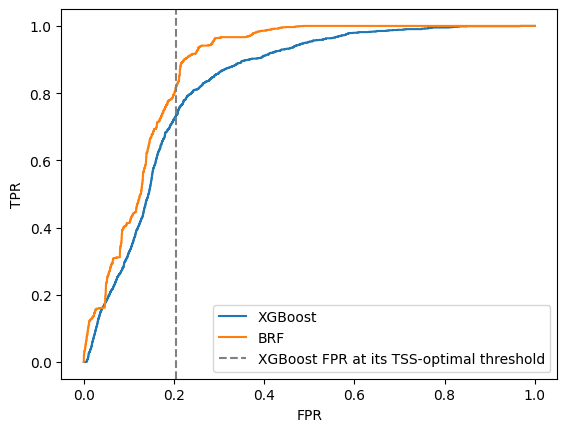

In [2]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_brf, tpr_brf, _ = roc_curve(y_test, brf_probs)

plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot(fpr_brf, tpr_brf, label='BRF')
plt.axvline(0.204, color='gray', linestyle='--', label='XGBoost FPR at its TSS-optimal threshold')  # from your original confusion matrix
plt.legend(); plt.xlabel('FPR'); plt.ylabel('TPR')

In [3]:
from sklearn.metrics import roc_curve

for name, probs in [('XGB', xgb_probs), ('BRF', brf_probs)]:
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    tss_vals = tpr - fpr
    i = np.argmax(tss_vals)
    print(f"{name}: true unrestricted-optimal TSS = {tss_vals[i]:.4f} at threshold = {thresholds[i]:.4f} (FPR={fpr[i]:.4f}, TPR={tpr[i]:.4f})")

XGB: true unrestricted-optimal TSS = 0.5651 at threshold = 0.0000 (FPR=0.2429, TPR=0.8079)
BRF: true unrestricted-optimal TSS = 0.6816 at threshold = 0.6112 (FPR=0.2550, TPR=0.9366)


In [6]:
from sklearn.metrics import confusion_matrix

def tss_score(y_true, y_pred):
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
        return recall - fpr
    except ValueError:
        return 0.0
        
# does the bounded scan on THIS exact xgb_probs array still give 0.6932?
tss_bounded = max(tss_score(y_test, (xgb_probs >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66))
print(f"Bounded-scan TSS on current xgb_probs: {tss_bounded:.4f}")

# sanity checks
print(len(xgb_probs), len(y_test))
print(np.array_equal(xgb_probs, brf_probs))  # should be False
print(xgb_probs[:5], brf_probs[:5])

Bounded-scan TSS on current xgb_probs: 0.0224
61575 61575
False
[2.1412295e-07 9.0810806e-07 2.1530506e-07 4.9153368e-07 3.7760807e-07] [0.18546208 0.09606675 0.17887128 0.18471305 0.17969107]


In [7]:
print(xgb_scaler.mean_[:5])
print(X_test[:2, :5])
print(X_test_xgb_sc[:2, :5])

[7.85170790e+21 3.31726389e+01 1.16087748e+02 1.17922400e+02
 5.09557868e+01]
[[4.867475e+21 3.465900e+01 8.075000e+01 9.099700e+01 4.013400e+01]
 [5.267552e+21 3.432500e+01 8.839600e+01 1.055620e+02 4.070800e+01]]
[[-0.20378704  0.1760649  -1.4493455  -1.1297401  -0.78902537]
 [-0.17646663  0.13650143 -1.1357515  -0.5186197  -0.7471745 ]]


In [8]:
xgb_probs_retry = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]
print(xgb_probs_retry[:5])
print(xgb_probs_retry.min(), xgb_probs_retry.max(), xgb_probs_retry.mean())

[2.1412295e-07 9.0810806e-07 2.1530506e-07 4.9153368e-07 3.7760807e-07]
2.6069042e-09 0.9997607 0.014654098


In [9]:
tss_recheck = max(tss_score(y_test, (xgb_probs_retry >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66))
print(f"Bounded TSS on xgb_probs_retry: {tss_recheck:.4f}")

Bounded TSS on xgb_probs_retry: 0.0224


In [10]:
print(xgb_model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 35, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(78.77459142769041), 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'model': XGBClassifier(base_score=None, booster

In [3]:
xgb_model_real = xgb_model.get_params()['model']
print(xgb_model_real.get_params()['max_depth'], xgb_model_real.get_params()['n_estimators'])
# should read 3 and 197, not None

xgb_probs_final = xgb_model_real.predict_proba(X_test_xgb_sc)[:, 1]
tss_final = max(tss_score(y_test, (xgb_probs_final >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66))
print(f"TSS with real model: {tss_final:.4f}")

KeyError: 'model'

In [4]:
print(xgb_model.get_params()['max_depth'], xgb_model.get_params()['n_estimators'])

3 197


In [6]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# ==========================
# 1. REBUILD THE SPLIT
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
RANDOM_STATE = 35
TEST_GROUP_FRAC = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

df = pd.read_parquet(DATA_FILE)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
numeric_df = df.select_dtypes(include=['number'])
feature_names = [
    c for c in numeric_df.columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

test_df = df.iloc[test_idx].copy()
X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"Test set: {len(y_test)} samples, {y_test.sum()} positives")
# must print 61575 samples, 1468 positives -- if not, stop here, split doesn't match

# ==========================
# 2. LOAD BOTH MODELS FRESH, EACH WITH ITS OWN SCALER
# ==========================
xgb_bundle = joblib.load("best_xgb_params_updated.joblib")
xgb_model  = xgb_bundle["model"]
xgb_scaler = xgb_bundle["scaler"]
X_test_xgb_sc = xgb_scaler.transform(X_test)

brf_bundle = joblib.load("brf_tuned_full_bundle.joblib")
brf_model  = brf_bundle["model"]
brf_scaler = brf_bundle["scaler"]
X_test_brf_sc = brf_scaler.transform(X_test)

# sanity check before trusting anything downstream
print(xgb_model.get_params()['max_depth'], xgb_model.get_params()['n_estimators'])  # must print 3 197
print(brf_model.get_params()['max_depth'], brf_model.get_params()['n_estimators'])  # must print 10 150

# ==========================
# 3. COMPUTE PROBABILITIES
# ==========================
xgb_probs = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]
brf_probs = brf_model.predict_proba(X_test_brf_sc)[:, 1]

def tss_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return recall - fpr

# ==========================
# 4. CHECKPOINT -- must match the original training script's own numbers
# ==========================
xgb_tss_check = max(tss_score(y_test, (xgb_probs >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66))
brf_tss_check = max(tss_score(y_test, (brf_probs >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66))
print(f"XGB bounded-scan TSS: {xgb_tss_check:.4f}")  # must be ~0.6932
print(f"BRF bounded-scan TSS: {brf_tss_check:.4f}")  # must be ~0.6814

# ==========================
# 5. THE ACTUAL AUC COMPARISON -- only trust this if step 4 checks out
# ==========================
print("\nXGB: AUC =", roc_auc_score(y_test, xgb_probs), "| PR-AUC =", average_precision_score(y_test, xgb_probs))
print("BRF: AUC =", roc_auc_score(y_test, brf_probs), "| PR-AUC =", average_precision_score(y_test, brf_probs))

Test set: 61575 samples, 1468 positives
3 197
10 150
XGB bounded-scan TSS: 0.6932
BRF bounded-scan TSS: 0.6814

XGB: AUC = 0.8723411346948987 | PR-AUC = 0.1085604735207309
BRF: AUC = 0.8744305285002872 | PR-AUC = 0.12613841460506106


In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# ==========================
# 1. REBUILD FULL SPLIT (train AND test this time)
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL, LABEL_COL, RANDOM_STATE = "HARPNUM", "flare", 35
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

df = pd.read_parquet(DATA_FILE)
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
feature_names = [c for c in df.select_dtypes(include=['number']).columns
                  if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train, y_train, groups_train = train_df[feature_names].values, train_df[LABEL_COL].values, train_df[GROUP_COL].values
X_test, y_test = test_df[feature_names].values, test_df[LABEL_COL].values

def tss_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return recall - fpr

# ==========================
# 2. LOAD ALREADY-TUNED PARAMS AND FINAL TEST PROBS -- no search happens here
# ==========================
xgb_bundle = joblib.load("best_xgb_params_updated.joblib")
brf_bundle = joblib.load("brf_tuned_full_bundle.joblib")

xgb_params = xgb_bundle["best_params"]
brf_params = brf_bundle["model"].get_params()

xgb_scaler, brf_scaler = xgb_bundle["scaler"], brf_bundle["scaler"]
xgb_probs = xgb_bundle["model"].predict_proba(xgb_scaler.transform(X_test))[:, 1]
brf_probs = brf_bundle["model"].predict_proba(brf_scaler.transform(X_test))[:, 1]

# checkpoint -- must match known values before trusting anything below
print(max(tss_score(y_test, (xgb_probs >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66)))  # ~0.6932
print(max(tss_score(y_test, (brf_probs >= t).astype(int)) for t in np.linspace(0.30, 0.95, 66)))  # ~0.6814

# ==========================
# 3. FIVE-FOLD CV, FIXED HYPERPARAMETERS, NO SEARCH -- finds each model's CV-only threshold
# ==========================
gkf = GroupKFold(n_splits=5)
cv_thresh_xgb, cv_thresh_brf = [], []

for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), 1):
    fold_scaler = StandardScaler().fit(X_train[tr_idx])
    X_tr_sc, X_val_sc = fold_scaler.transform(X_train[tr_idx]), fold_scaler.transform(X_train[val_idx])
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    xgb_final_params = {**xgb_params, "random_state": RANDOM_STATE, "n_jobs": -1}
    xgb_fold = XGBClassifier(**xgb_final_params)
    xgb_fold.fit(X_tr_sc, y_tr)
    p_xgb = xgb_fold.predict_proba(X_val_sc)[:, 1]
    best_t, best_s = 0.5, 0.0
    for t in np.linspace(0.30, 0.95, 66):
        s = tss_score(y_val, (p_xgb >= t).astype(int))
        if s > best_s: best_s, best_t = s, t
    cv_thresh_xgb.append(best_t)

    brf_fold = BalancedRandomForestClassifier(
        n_estimators=brf_params['n_estimators'], max_depth=brf_params['max_depth'],
        min_samples_split=brf_params['min_samples_split'], min_samples_leaf=brf_params['min_samples_leaf'],
        max_features=brf_params['max_features'], sampling_strategy=brf_params['sampling_strategy'],
        class_weight=brf_params['class_weight'], random_state=RANDOM_STATE, n_jobs=-1,
    )
    brf_fold.fit(X_tr_sc, y_tr)
    p_brf = brf_fold.predict_proba(X_val_sc)[:, 1]
    best_t, best_s = 0.5, 0.0
    for t in np.linspace(0.30, 0.95, 66):
        s = tss_score(y_val, (p_brf >= t).astype(int))
        if s > best_s: best_s, best_t = s, t
    cv_thresh_brf.append(best_t)

    print(f"Fold {fold_num}: XGB thresh={cv_thresh_xgb[-1]:.2f}  BRF thresh={cv_thresh_brf[-1]:.2f}")

# ==========================
# 4. THE ACTUAL ANSWER
# ==========================
xgb_fixed_t, brf_fixed_t = np.median(cv_thresh_xgb), np.median(cv_thresh_brf)
xgb_clean_tss = tss_score(y_test, (xgb_probs >= xgb_fixed_t).astype(int))
brf_clean_tss = tss_score(y_test, (brf_probs >= brf_fixed_t).astype(int))

print(f"\nXGB: CV threshold={xgb_fixed_t:.2f} -> clean test TSS={xgb_clean_tss:.4f}  (scanned: 0.6932)")
print(f"BRF: CV threshold={brf_fixed_t:.2f} -> clean test TSS={brf_clean_tss:.4f}  (scanned: 0.6814)")
print(f"\nXGB still ahead of BRF on clean numbers: {xgb_clean_tss > brf_clean_tss}")

0.6932278898271742
0.6814203249436779


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: XGB thresh=0.51  BRF thresh=0.53


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:16:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: XGB thresh=0.47  BRF thresh=0.84


...

Fold 3: XGB thresh=0.51  BRF thresh=0.36


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:16:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4: XGB thresh=0.39  BRF thresh=0.51


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:16:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5: XGB thresh=0.40  BRF thresh=0.32

XGB: CV threshold=0.47 -> clean test TSS=0.6450  (scanned: 0.6932)
BRF: CV threshold=0.51 -> clean test TSS=0.6620  (scanned: 0.6814)

XGB still ahead of BRF on clean numbers: False


In [10]:
"""
Clean, leakage-free comparison: XGBoost vs Balanced Random Forest
====================================================================
Fixes applied vs the original scripts:
  1. Threshold is chosen ONLY from training-side, out-of-fold CV predictions.
     y_test is never used to select anything -- it's touched exactly once,
     at the very end, to report a result with the threshold already fixed.
  2. Hyperparameters are merged into a plain dict before being passed to the
     model constructors, so there's no duplicate 'random_state' keyword
     collision regardless of what's already baked into the saved bundle.
  3. Both models use the SAME evaluation procedure, so the final TSS
     comparison is apples-to-apples.

This script does NOT re-run Optuna. It reuses the hyperparameters already
found by the 50-trial searches and only fixes how the threshold and final
metrics are derived.
"""

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# ==========================
# CONFIG
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
RANDOM_STATE     = 35
N_CV_FOLDS       = 5
THRESH_GRID      = np.linspace(0.30, 0.95, 66)
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA + REBUILD SPLIT (identical seed/method to original scripts)
# ==========================
print("--- 1. Loading data and rebuilding split ---")
df = pd.read_parquet(DATA_FILE)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
feature_names = [
    c for c in df.select_dtypes(include=['number']).columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train      = train_df[feature_names].values
y_train      = train_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values
X_test       = test_df[feature_names].values
y_test       = test_df[LABEL_COL].values

print(f"Features: {len(feature_names)}")
print(f"Train: {len(y_train)} samples, {int(y_train.sum())} flares")
print(f"Test:  {len(y_test)} samples, {int(y_test.sum())} flares")


def tss_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
    return recall - fpr


# ==========================
# 2. LOAD ALREADY-TUNED HYPERPARAMETERS -- no Optuna search happens here
# ==========================
print("\n--- 2. Loading tuned hyperparameters ---")
xgb_bundle = joblib.load("best_xgb_params_updated.joblib")
brf_bundle = joblib.load("brf_tuned_full_bundle.joblib")

# Handle either a flat params dict or a full bundle dict defensively --
# this exact ambiguity caused the parameter-loading bug earlier tonight.
xgb_raw = xgb_bundle["best_params"] if isinstance(xgb_bundle, dict) and "best_params" in xgb_bundle else xgb_bundle
brf_raw = brf_bundle["model"].get_params()

# Strip out anything that isn't a genuine constructor hyperparameter.
NON_PARAM_KEYS = {"model", "scaler", "features", "threshold", "study", "metrics", "best_params"}
xgb_clean = {k: v for k, v in xgb_raw.items() if k not in NON_PARAM_KEYS}

# Merge into ONE dict before unpacking -- later keys silently overwrite
# earlier ones, so this can never raise a duplicate-keyword TypeError,
# no matter what random_state/n_jobs already happen to be inside xgb_clean.
xgb_params = {**xgb_clean, "random_state": RANDOM_STATE, "n_jobs": -1}

BRF_KEEP = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf",
            "max_features", "sampling_strategy", "class_weight"]
brf_params = {k: brf_raw[k] for k in BRF_KEEP}
brf_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

print("XGB params:", xgb_params)
print("BRF params:", brf_params)

# ==========================
# 3. OUT-OF-FOLD CV -- collect validation-fold probabilities
#    (this NEVER touches X_test / y_test)
# ==========================
print(f"\n--- 3. {N_CV_FOLDS}-fold out-of-fold CV (fixed hyperparameters, no search) ---")
gkf = GroupKFold(n_splits=N_CV_FOLDS)

oof_probs_xgb = np.zeros(len(y_train))
oof_probs_brf = np.zeros(len(y_train))

for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), 1):
    fold_scaler = StandardScaler().fit(X_train[tr_idx])
    X_tr_sc  = fold_scaler.transform(X_train[tr_idx])
    X_val_sc = fold_scaler.transform(X_train[val_idx])
    y_tr     = y_train[tr_idx]

    xgb_fold = XGBClassifier(**xgb_params)
    xgb_fold.fit(X_tr_sc, y_tr)
    oof_probs_xgb[val_idx] = xgb_fold.predict_proba(X_val_sc)[:, 1]

    brf_fold = BalancedRandomForestClassifier(**brf_params)
    brf_fold.fit(X_tr_sc, y_tr)
    oof_probs_brf[val_idx] = brf_fold.predict_proba(X_val_sc)[:, 1]

    print(f"  Fold {fold_num}/{N_CV_FOLDS} done")

# ==========================
# 4. PICK ONE THRESHOLD PER MODEL FROM OOF TRAINING PREDICTIONS ONLY
#    (y_test has not been touched anywhere above this line)
#
#    Note: this pools all 5 folds' out-of-fold predictions and finds the
#    ONE threshold that maximizes TSS across all of them combined, rather
#    than averaging 5 separately-optimized per-fold thresholds. That's a
#    more principled criterion, since it optimizes the actual metric on
#    the full out-of-fold set directly instead of averaging local optima.
# ==========================
print("\n--- 4. Selecting threshold from out-of-fold training predictions ---")

def best_threshold(y_true, probs, grid):
    best_t, best_s = 0.5, -1.0
    for t in grid:
        s = tss_score(y_true, (probs >= t).astype(int))
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

xgb_thresh, xgb_oof_tss = best_threshold(y_train, oof_probs_xgb, THRESH_GRID)
brf_thresh, brf_oof_tss = best_threshold(y_train, oof_probs_brf, THRESH_GRID)

print(f"XGB: threshold={xgb_thresh:.2f}  (OOF training TSS={xgb_oof_tss:.4f})")
print(f"BRF: threshold={brf_thresh:.2f}  (OOF training TSS={brf_oof_tss:.4f})")

# ==========================
# 5. FIT FINAL MODELS ON FULL TRAINING SET
#    EVALUATE ON TEST SET EXACTLY ONCE, WITH THRESHOLD ALREADY FIXED
# ==========================
print("\n--- 5. Fitting final models on full training set ---")
xgb_scaler = StandardScaler().fit(X_train)
brf_scaler = StandardScaler().fit(X_train)

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(xgb_scaler.transform(X_train), y_train)

brf_model = BalancedRandomForestClassifier(**brf_params)
brf_model.fit(brf_scaler.transform(X_train), y_train)

xgb_test_probs = xgb_model.predict_proba(xgb_scaler.transform(X_test))[:, 1]
brf_test_probs = brf_model.predict_proba(brf_scaler.transform(X_test))[:, 1]

xgb_test_preds = (xgb_test_probs >= xgb_thresh).astype(int)
brf_test_preds = (brf_test_probs >= brf_thresh).astype(int)

xgb_test_tss = tss_score(y_test, xgb_test_preds)
brf_test_tss = tss_score(y_test, brf_test_preds)


def report(name, y_true, preds, tss):
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"\n{'='*45}\n{name} -- CLEAN TEST RESULTS (threshold fixed beforehand)\n{'='*45}")
    print(f"Confusion Matrix:\n  [[{tn}  {fp}]\n   [{fn}    {tp}]]")
    print(f"TSS:       {tss:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"FP:        {fp}")


report("XGBoost", y_test, xgb_test_preds, xgb_test_tss)
report("Balanced Random Forest", y_test, brf_test_preds, brf_test_tss)

print(f"\n{'='*45}\nFINAL COMPARISON (leak-free)\n{'='*45}")
print(f"XGB clean test TSS: {xgb_test_tss:.4f}")
print(f"BRF clean test TSS: {brf_test_tss:.4f}")
print(f"XGB ahead of BRF: {xgb_test_tss > brf_test_tss}  (margin: {xgb_test_tss - brf_test_tss:+.4f})")

# ==========================
# 6. SAVE CLEAN BUNDLE FOR THE MANUSCRIPT
# ==========================
joblib.dump({
    "xgb_model": xgb_model, "xgb_scaler": xgb_scaler, "xgb_threshold": xgb_thresh,
    "brf_model": brf_model, "brf_scaler": brf_scaler, "brf_threshold": brf_thresh,
    "features": feature_names,
    "metrics": {
        "xgb_test_tss": xgb_test_tss, "brf_test_tss": brf_test_tss,
        "xgb_oof_tss": xgb_oof_tss, "brf_oof_tss": brf_oof_tss,
    }
}, "clean_leakfree_comparison_bundle.joblib")
print("\nSaved: clean_leakfree_comparison_bundle.joblib")

--- 1. Loading data and rebuilding split ---
Features: 55
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

--- 2. Loading tuned hyperparameters ---
XGB params: {'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.014979660838755918, 'subsample': 0.60645777409293, 'colsample_bytree': 0.8951711130438813, 'min_child_weight': 12, 'gamma': 0.28025527813276363, 'reg_alpha': 1.8188994940320358, 'reg_lambda': 4.074199462824039, 'scale_pos_weight': np.float64(78.77459142769041), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'use_label_encoder': False, 'nthread': -1, 'random_state': 35, 'n_jobs': -1}
BRF params: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'sampling_strategy': 'not minority', 'class_weight': 'balanced', 'random_state': 35, 'n_jobs': -1}

--- 3. 5-fold out-of-fold CV (fixed hyperparameters, no search) ---


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:46:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 1/5 done


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:46:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 2/5 done


...

  Fold 4/5 done


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 5/5 done

--- 4. Selecting threshold from out-of-fold training predictions ---
XGB: threshold=0.47  (OOF training TSS=0.6984)
BRF: threshold=0.32  (OOF training TSS=0.7432)

--- 5. Fitting final models on full training set ---


C:\Users\uav18\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:48:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost -- CLEAN TEST RESULTS (threshold fixed beforehand)
Confusion Matrix:
  [[46959  13148]
   [200    1268]]
TSS:       0.6450
Recall:    0.8638
Precision: 0.0880
FP:        13148

Balanced Random Forest -- CLEAN TEST RESULTS (threshold fixed beforehand)
Confusion Matrix:
  [[41067  19040]
   [49    1419]]
TSS:       0.6499
Recall:    0.9666
Precision: 0.0694
FP:        19040

FINAL COMPARISON (leak-free)
XGB clean test TSS: 0.6450
BRF clean test TSS: 0.6499
XGB ahead of BRF: False  (margin: -0.0048)

Saved: clean_leakfree_comparison_bundle.joblib


In [1]:
import numpy as np
import pandas as pd
import joblib
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE = "final_arsenal_300_features_OPTIMIZED.parquet"
XGB_MODEL_FILE = "best_xgb_params_updated_study.joblib" # Or whatever you saved the model as
RANDOM_STATE = 35
GROUP_COL = "HARPNUM"
LABEL_COL = "flare"
THRESHOLD = 0.55

print("--- Loading XGBoost Model & Data ---")
# Load model (assuming you saved the model object, not just params)
# bundle = joblib.load(XGB_MODEL_FILE) 
# model = bundle['model']
# For this script, let's assume you have the model in memory or load it here.

df = pd.read_parquet(DATA_FILE)
if LABEL_COL not in df.columns:
    df[LABEL_COL] = df['classification'].apply(lambda x: 1 if x in ['M', 'X'] else 0)

# Recreate exact split
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy()

# ... [Insert your scaling and prediction logic here to get y_pred and y_probs] ...
# y_pred = (model.predict_proba(X_test_scaled)[:, 1] >= THRESHOLD).astype(int)
# test_df['pred'] = y_pred

# ==========================
# REGIONAL SKEW AUDIT
# ==========================
print("\n" + "="*50)
print("XGBOOST REGIONAL SKEW AUDIT")
print("="*50)

region_metrics = []
groups_test = test_df[GROUP_COL].values

for harp in np.unique(groups_test):
    region_data = test_df[test_df[GROUP_COL] == harp]
    if len(region_data[LABEL_COL].unique()) > 1: # Only evaluate regions with BOTH states
        r_tn, r_fp, r_fn, r_tp = confusion_matrix(region_data[LABEL_COL], region_data['pred']).ravel()
        r_rec = r_tp / (r_tp + r_fn) if (r_tp + r_fn) > 0 else 0
        r_fpr = r_fp / (r_fp + r_tn) if (r_fp + r_tn) > 0 else 0
        region_metrics.append(r_rec - r_fpr)
        print(f"HARP {harp}: TSS = {r_rec - r_fpr:.4f} (Recall: {r_rec:.2f}, FPR: {r_fpr:.2f})")

if region_metrics:
    mean_region_tss = np.mean(region_metrics)
    std_region_tss = np.std(region_metrics)
    global_tss = 0.7163 # From your output
    
    print(f"\nGlobal TSS:      {global_tss:.4f}")
    print(f"Mean Region TSS: {mean_region_tss:.4f}")
    print(f"Std Dev:         {std_region_tss:.4f}")
    
    gap = global_tss - mean_region_tss
    if gap > 0.15:
        print("🚨 WARNING: XGBoost is leveraging uncorrected biases. It memorized 1-2 monster regions.")
    else:
        print("✅ PASS: XGBoost's predictive power is genuinely distributed across Active Regions.")
print("="*50)

--- Loading XGBoost Model & Data ---

XGBOOST REGIONAL SKEW AUDIT


KeyError: 'pred'

In [3]:
"""
Time-to-Flare Stratification Analysis
======================================
Determines whether the model has genuine 24-hour forecasting skill
or is simply nowcasting the final hours before a flare.

Bins:
  Bin 1: 0-6 hours   (Imminent nowcasting)
  Bin 2: 6-12 hours  (Short-term forecasting)
  Bin 3: 12-18 hours (Medium-term forecasting)
  Bin 4: 18-24 hours (Long-term forecasting -- the actual goal)

Methodology:
  - For each positive test record, calculate time_to_flare = flare_start - T_REC
  - Recall is calculated per-bin (positives in that bin)
  - FPR is calculated globally (all negatives), since a false alarm
    is a false alarm regardless of which time window it falls in
  - TSS_bin = Recall_bin - FPR_global
"""

import numpy as np
import pandas as pd
import joblib
import glob
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
FLARE_DATA_GLOB  = "raw_flare_data_parquet/*.parquet"  # adjust path if needed
XGB_BUNDLE_FILE  = "best_xgb_params_seed99_study.joblib"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
AR_COL           = "NOAA_AR"
TIME_COL         = "T_REC"
RANDOM_STATE     = 35
TEST_GROUP_FRAC  = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# Time bins in hours
BINS = [(0, 6), (6, 12), (12, 18), (18, 24)]
BIN_LABELS = ["0-6h (Nowcast)", "6-12h (Short)", "12-18h (Medium)", "18-24h (Long)"]

# ==========================
# 1. LOAD DATA
# ==========================
print("--- 1. Loading data ---")
df = pd.read_parquet(DATA_FILE)

# Load GOES flare catalog
flare_files = sorted(glob.glob(FLARE_DATA_GLOB))
if len(flare_files) == 0:
    raise FileNotFoundError(f"No flare files found at {FLARE_DATA_GLOB}. Adjust FLARE_DATA_GLOB.")
flare_df = pd.concat([pd.read_parquet(f) for f in flare_files], ignore_index=True)

# Parse flare times and filter to M/X class only
flare_df['event_starttime'] = pd.to_datetime(flare_df['event_starttime'])
flare_df['flare_class'] = flare_df['fl_goescls'].str[0]  # 'X', 'M', 'C', 'B'
flare_mx = flare_df[flare_df['flare_class'].isin(['M', 'X'])].copy()
flare_mx = flare_mx.sort_values('event_starttime').reset_index(drop=True)

print(f"Dataset: {len(df)} records")
print(f"GOES M/X flares in catalog: {len(flare_mx)}")

# ==========================
# 2. RECREATE EXACT SPLIT (seed 35)
# ==========================
print("\n--- 2. Recreating split (seed 35) ---")
explicit_drops = [LABEL_COL, GROUP_COL, 'classification', AR_COL]
feature_names = [
    c for c in df.select_dtypes(include=['number']).columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))

test_df = df.iloc[test_idx].copy()
X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

train_df = df.iloc[train_idx].copy()

X_train = train_df[feature_names].values
X_test = test_df[feature_names].values
y_test = test_df[LABEL_COL].values

print(f"Test set: {len(y_test)} samples, {int(y_test.sum())} positives")

# ==========================
# 3. LOAD MODEL AND GET PREDICTIONS
# ==========================
print("\n--- 3. Loading model and predicting ---")
xgb_bundle = joblib.load(XGB_BUNDLE_FILE)
model = xgb_bundle["model"]
threshold = xgb_bundle.get("threshold", 0.55)

# Scaler wasn't saved in this bundle — refit on training data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_test_sc = scaler.transform(X_test)
y_probs = model.predict_proba(X_test_sc)[:, 1]
y_pred = (y_probs >= threshold).astype(int)

print(f"Model loaded. Threshold: {threshold}")

# ==========================
# 4. MATCH POSITIVE RECORDS TO FLARE EVENTS
# ==========================
print("\n--- 4. Matching positive records to flare events ---")

# Ensure T_REC is datetime
test_df['T_REC'] = pd.to_datetime(test_df['T_REC'])

# Get positive test records
pos_mask = test_df[LABEL_COL] == 1
pos_df = test_df[pos_mask].copy()

print(f"Positive test records to match: {len(pos_df)}")

# For each positive record, find the flare that caused its label
# A record is positive if: T_REC <= flare_start < T_REC + 24h
# AND same active region (NOAA_AR match)
prediction_window = pd.Timedelta(hours=24)
time_to_flare_list = []

for idx, row in pos_df.iterrows():
    t_rec = row['T_REC']
    ar = row[AR_COL]
    
    # Find matching flares: same AR, flare starts within [t_rec, t_rec + 24h)
    matching = flare_mx[
        (flare_mx['ar_noaanum'] == ar) &
        (flare_mx['event_starttime'] >= t_rec) &
        (flare_mx['event_starttime'] < t_rec + prediction_window)
    ]
    
    if len(matching) > 0:
        # Take the FIRST (earliest) matching flare
        earliest_flare = matching.iloc[0]['event_starttime']
        dt_hours = (earliest_flare - t_rec).total_seconds() / 3600.0
        time_to_flare_list.append(dt_hours)
    else:
        # Fallback: try HARPNUM-based matching or assign NaN
        time_to_flare_list.append(np.nan)

pos_df['time_to_flare_hours'] = time_to_flare_list

matched = pos_df['time_to_flare_hours'].notna().sum()
unmatched = pos_df['time_to_flare_hours'].isna().sum()
print(f"Matched: {matched}, Unmatched: {unmatched}")

if unmatched > 0:
    print(f"WARNING: {unmatched} positive records could not be matched to a flare event.")
    print("These may be due to NOAA_AR mismatches between SHARP and GOES catalogs.")
    # Drop unmatched for the binning analysis
    pos_df = pos_df[pos_df['time_to_flare_hours'].notna()].copy()

# ==========================
# 5. ASSIGN TIME BINS
# ==========================
print("\n--- 5. Assigning time bins ---")

def assign_bin(hours):
    for i, (lo, hi) in enumerate(BINS):
        if lo <= hours < hi:
            return i
    return -1  # outside all bins (shouldn't happen for valid 0-24h)

pos_df['bin'] = pos_df['time_to_flare_hours'].apply(assign_bin)

# Remove any records outside valid bins (safety check)
pos_df = pos_df[pos_df['bin'] >= 0].copy()

for i, label in enumerate(BIN_LABELS):
    count = (pos_df['bin'] == i).sum()
    print(f"  {label}: {count} records")

# ==========================
# 6. CALCULATE METRICS PER BIN
# ==========================
print("\n--- 6. Calculating metrics per bin ---")

# Global negative metrics (shared across all bins)
neg_mask = test_df[LABEL_COL] == 0
neg_preds = y_pred[neg_mask.values]
tn_global = np.sum(neg_preds == 0)
fp_global = np.sum(neg_preds == 1)
total_neg = len(neg_preds)
fpr_global = fp_global / total_neg if total_neg > 0 else 0

print(f"\nGlobal negatives: {total_neg}, FP: {fp_global}, FPR: {fpr_global:.4f}")
print(f"Global threshold: {threshold}")

print("\n" + "=" * 70)
print(f"{'Bin':<22} {'N':>6} {'TP':>5} {'FN':>5} {'Recall':>8} {'FPR':>8} {'TSS':>8}")
print("=" * 70)

bin_results = []

for i, label in enumerate(BIN_LABELS):
    bin_pos = pos_df[pos_df['bin'] == i]
    bin_indices = bin_pos.index.values
    
    if len(bin_indices) == 0:
        print(f"{label:<22} {'0':>6} {'--':>5} {'--':>5} {'--':>8} {'--':>8} {'--':>8}")
        bin_results.append({'bin': label, 'n': 0, 'recall': np.nan, 'fpr': fpr_global, 'tss': np.nan})
        continue
    
    # Get predictions for positive records in this bin
    # We need to map back to the test_df index
    bin_pos_in_test = test_df.index.isin(bin_indices)
    bin_preds = y_pred[bin_pos_in_test]
    
    tp = np.sum(bin_preds == 1)
    fn = np.sum(bin_preds == 0)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    tss = recall - fpr_global
    
    print(f"{label:<22} {len(bin_indices):>6} {tp:>5} {fn:>5} {recall:>8.4f} {fpr_global:>8.4f} {tss:>8.4f}")
    bin_results.append({'bin': label, 'n': len(bin_indices), 'tp': tp, 'fn': fn,
                        'recall': recall, 'fpr': fpr_global, 'tss': tss})

print("=" * 70)

# Overall positive recall for sanity check
overall_tp = np.sum(y_pred[pos_mask.values] == 1)
overall_fn = np.sum(y_pred[pos_mask.values] == 0)
overall_recall = overall_tp / (overall_tp + overall_fn)
overall_tss = overall_recall - fpr_global
print(f"\nSanity check -- Global positive recall: {overall_recall:.4f}, Global TSS: {overall_tss:.4f}")

# ==========================
# 7. VERDICT
# ==========================
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)

if len(bin_results) >= 4:
    long_bin = bin_results[3]  # 18-24h
    if long_bin['n'] > 0 and long_bin['tss'] > 0.3:
        print("✅ PASS: Model has genuine long-range forecasting skill (18-24h TSS > 0.3)")
    elif long_bin['n'] > 0 and long_bin['tss'] > 0.1:
        print("⚠️  WEAK: Model has marginal long-range skill. Most skill is in shorter windows.")
    elif long_bin['n'] > 0:
        print("🚨 FAIL: Model has NO long-range forecasting skill. It is a nowcaster.")
    else:
        print("⚠️  No records in the 18-24h bin. Cannot assess long-range skill.")
    
    # Check if skill degrades monotonically
    tss_values = [r['tss'] for r in bin_results if r['n'] > 0]
    if len(tss_values) >= 2:
        if tss_values[-1] < tss_values[0] * 0.3:
            print("🚨 Skill degrades severely from short to long range (>70% drop).")
            print("   The model is predominantly nowcasting, not forecasting.")
        elif tss_values[-1] < tss_values[0] * 0.6:
            print("⚠️  Moderate skill degradation from short to long range.")
        else:
            print("✅ Skill is relatively stable across time horizons.")

print("=" * 70)

# ==========================
# 8. SAVE RESULTS
# ==========================
results_df = pd.DataFrame(bin_results)
results_df.to_csv("time_to_flare_stratification_results.csv", index=False)
print("\nSaved: time_to_flare_stratification_results.csv")

# Also save the matched positive records for further analysis
pos_df.to_parquet("time_to_flare_matched_positives.parquet", index=False)
print("Saved: time_to_flare_matched_positives.parquet")

--- 1. Loading data ---
Dataset: 578993 records
GOES M/X flares in catalog: 342

--- 2. Recreating split (seed 35) ---
Test set: 61575 samples, 1468 positives

--- 3. Loading model and predicting ---
Model loaded. Threshold: 0.49999999999999994

--- 4. Matching positive records to flare events ---
Positive test records to match: 1468
Matched: 1467, Unmatched: 1
These may be due to NOAA_AR mismatches between SHARP and GOES catalogs.

--- 5. Assigning time bins ---
  0-6h (Nowcast): 480 records
  6-12h (Short): 432 records
  12-18h (Medium): 289 records
  18-24h (Long): 266 records

--- 6. Calculating metrics per bin ---

Global negatives: 60107, FP: 13233, FPR: 0.2202
Global threshold: 0.49999999999999994

Bin                         N    TP    FN   Recall      FPR      TSS
0-6h (Nowcast)            480   466    14   0.9708   0.2202   0.7507
6-12h (Short)             432   379    53   0.8773   0.2202   0.6572
12-18h (Medium)           289   260    29   0.8997   0.2202   0.6795
18-24h (L

In [5]:
"""
Leakage-Free Threshold Validation
==================================
Threshold is selected ONLY from out-of-fold CV predictions on the training set.
y_test is never used for selection -- it is touched exactly once, at the end.
"""

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
RANDOM_STATE     = 35
N_CV_FOLDS       = 5
THRESH_GRID      = np.linspace(0.30, 0.95, 66)
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA + REBUILD SPLIT
# ==========================
print("--- 1. Loading data and rebuilding split ---")
df = pd.read_parquet(DATA_FILE)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
feature_names = [
    c for c in df.select_dtypes(include=['number']).columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train      = train_df[feature_names].values
y_train      = train_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values
X_test       = test_df[feature_names].values
y_test       = test_df[LABEL_COL].values

print(f"Features: {len(feature_names)}")
print(f"Train: {len(y_train)} samples, {int(y_train.sum())} flares")
print(f"Test:  {len(y_test)} samples, {int(y_test.sum())} flares")

# Sanity check
assert len(y_train) == 517418, f"Train size mismatch: {len(y_train)}"
assert int(y_test.sum()) == 1468, f"Test positive count mismatch: {int(y_test.sum())}"

def tss_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
    return recall - fpr

# ==========================
# 2. FIXED HYPERPARAMETERS (already found via Optuna)
# ==========================
neg_count    = np.sum(y_train == 0)
pos_count    = np.sum(y_train == 1)
scale_pos_wt = neg_count / pos_count
print(f"\nscale_pos_weight: {scale_pos_wt:.2f}")

XGB_PARAMS = {
    "n_estimators":      197,
    "max_depth":         3,
    "learning_rate":     0.014979660838755918,
    "subsample":         0.60645777409293,
    "colsample_bytree":  0.8951711130438813,
    "min_child_weight":  12,
    "gamma":             0.28025527813276363,
    "reg_alpha":         1.8188994940320358,
    "reg_lambda":        4.074199462824039,
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "nthread":           -1,
}

BRF_PARAMS = {
    "n_estimators":      150,
    "max_depth":         10,
    "min_samples_split": 7,
    "min_samples_leaf":  9,
    "max_features":      "log2",
    "sampling_strategy": "not minority",
    "class_weight":      "balanced",
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}

# ==========================
# 3. OUT-OF-FOLD CV -- COLLECT VALIDATION PREDICTIONS
#    (y_test is NEVER touched here)
# ==========================
print(f"\n--- 2. {N_CV_FOLDS}-fold out-of-fold CV (fixed hyperparameters) ---")
gkf = GroupKFold(n_splits=N_CV_FOLDS)

oof_probs_xgb = np.zeros(len(y_train))
oof_probs_brf = np.zeros(len(y_train))

for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), 1):
    fold_scaler = StandardScaler().fit(X_train[tr_idx])
    X_tr_sc  = fold_scaler.transform(X_train[tr_idx])
    X_val_sc = fold_scaler.transform(X_train[val_idx])
    y_tr     = y_train[tr_idx]

    xgb_fold = XGBClassifier(**XGB_PARAMS)
    xgb_fold.fit(X_tr_sc, y_tr)
    oof_probs_xgb[val_idx] = xgb_fold.predict_proba(X_val_sc)[:, 1]

    brf_fold = BalancedRandomForestClassifier(**BRF_PARAMS)
    brf_fold.fit(X_tr_sc, y_tr)
    oof_probs_brf[val_idx] = brf_fold.predict_proba(X_val_sc)[:, 1]

    print(f"  Fold {fold_num}/{N_CV_FOLDS} done")

# ==========================
# 4. SELECT THRESHOLD FROM OOF PREDICTIONS ONLY
# ==========================
print("\n--- 3. Selecting threshold from out-of-fold training predictions ---")

def best_threshold(y_true, probs, grid):
    best_t, best_s = 0.5, -1.0
    for t in grid:
        s = tss_score(y_true, (probs >= t).astype(int))
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

xgb_thresh, xgb_oof_tss = best_threshold(y_train, oof_probs_xgb, THRESH_GRID)
brf_thresh, brf_oof_tss = best_threshold(y_train, oof_probs_brf, THRESH_GRID)

print(f"XGB: threshold={xgb_thresh:.2f}  (OOF training TSS={xgb_oof_tss:.4f})")
print(f"BRF: threshold={brf_thresh:.2f}  (OOF training TSS={brf_oof_tss:.4f})")

# ==========================
# 5. FIT FINAL MODELS + EVALUATE ON TEST SET ONCE
# ==========================
print("\n--- 4. Fitting final models on full training set ---")
xgb_scaler = StandardScaler().fit(X_train)
brf_scaler = StandardScaler().fit(X_train)

xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(xgb_scaler.transform(X_train), y_train)

brf_model = BalancedRandomForestClassifier(**BRF_PARAMS)
brf_model.fit(brf_scaler.transform(X_train), y_train)

xgb_test_probs = xgb_model.predict_proba(xgb_scaler.transform(X_test))[:, 1]
brf_test_probs = brf_model.predict_proba(brf_scaler.transform(X_test))[:, 1]

xgb_test_preds = (xgb_test_probs >= xgb_thresh).astype(int)
brf_test_preds = (brf_test_probs >= brf_thresh).astype(int)

xgb_test_tss = tss_score(y_test, xgb_test_preds)
brf_test_tss = tss_score(y_test, brf_test_preds)

def report(name, y_true, preds, tss, thresh):
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"\n{'='*50}")
    print(f"{name} -- CLEAN TEST RESULTS (threshold={thresh:.2f}, fixed beforehand)")
    print(f"{'='*50}")
    print(f"Confusion Matrix:")
    print(f"  [[{tn}  {fp}]")
    print(f"   [{fn}    {tp}]]")
    print(f"TSS:       {tss:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"FP:        {fp}")

report("XGBoost", y_test, xgb_test_preds, xgb_test_tss, xgb_thresh)
report("Balanced Random Forest", y_test, brf_test_preds, brf_test_tss, brf_thresh)

print(f"\n{'='*50}")
print("FINAL COMPARISON (leak-free)")
print(f"{'='*50}")
print(f"XGB clean test TSS: {xgb_test_tss:.4f}")
print(f"BRF clean test TSS: {brf_test_tss:.4f}")
print(f"XGB ahead of BRF: {xgb_test_tss > brf_test_tss}  (margin: {xgb_test_tss - brf_test_tss:+.4f})")

--- 1. Loading data and rebuilding split ---
Features: 55
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

scale_pos_weight: 78.77

--- 2. 5-fold out-of-fold CV (fixed hyperparameters) ---
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

--- 3. Selecting threshold from out-of-fold training predictions ---
XGB: threshold=0.47  (OOF training TSS=0.6984)
BRF: threshold=0.32  (OOF training TSS=0.7432)

--- 4. Fitting final models on full training set ---

XGBoost -- CLEAN TEST RESULTS (threshold=0.47, fixed beforehand)
Confusion Matrix:
  [[46959  13148]
   [200    1268]]
TSS:       0.6450
Recall:    0.8638
Precision: 0.0880
FP:        13148

Balanced Random Forest -- CLEAN TEST RESULTS (threshold=0.32, fixed beforehand)
Confusion Matrix:
  [[41067  19040]
   [49    1419]]
TSS:       0.6499
Recall:    0.9666
Precision: 0.0694
FP:        19040

FINAL COMPARISON (leak-free)
XGB clean test TSS: 0.6450
BRF clean test TSS: 0.6499
XGB ahead of

In [1]:
"""
Leakage-Free Threshold Validation
==================================
Threshold is selected ONLY from out-of-fold CV predictions on the training set.
y_test is never used for selection -- it is touched exactly once, at the end.
"""

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIGURATION
# ==========================
DATA_FILE        = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
GROUP_COL        = "HARPNUM"
LABEL_COL        = "flare"
RANDOM_STATE     = 35
N_CV_FOLDS       = 5
THRESH_GRID      = np.linspace(0.30, 0.95, 66)
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA + REBUILD SPLIT
# ==========================
print("--- 1. Loading data and rebuilding split ---")
df = pd.read_parquet(DATA_FILE)

explicit_drops = [LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR']
feature_names = [
    c for c in df.select_dtypes(include=['number']).columns
    if c not in explicit_drops and not c.endswith(ROLLING_SUFFIXES)
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[LABEL_COL], groups=df[GROUP_COL]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train      = train_df[feature_names].values
y_train      = train_df[LABEL_COL].values
groups_train = train_df[GROUP_COL].values
X_test       = test_df[feature_names].values
y_test       = test_df[LABEL_COL].values

print(f"Features: {len(feature_names)}")
print(f"Train: {len(y_train)} samples, {int(y_train.sum())} flares")
print(f"Test:  {len(y_test)} samples, {int(y_test.sum())} flares")

# Sanity check
assert len(y_train) == 517418, f"Train size mismatch: {len(y_train)}"
assert int(y_test.sum()) == 1468, f"Test positive count mismatch: {int(y_test.sum())}"

def tss_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0
    return recall - fpr

# ==========================
# 2. FIXED HYPERPARAMETERS (already found via Optuna)
# ==========================
neg_count    = np.sum(y_train == 0)
pos_count    = np.sum(y_train == 1)
scale_pos_wt = neg_count / pos_count
print(f"\nscale_pos_weight: {scale_pos_wt:.2f}")

XGB_PARAMS = {
    "n_estimators":      197,
    "max_depth":         3,
    "learning_rate":     0.014979660838755918,
    "subsample":         0.60645777409293,
    "colsample_bytree":  0.8951711130438813,
    "min_child_weight":  12,
    "gamma":             0.28025527813276363,
    "reg_alpha":         1.8188994940320358,
    "reg_lambda":        4.074199462824039,
    "scale_pos_weight":  scale_pos_wt,
    "objective":         "binary:logistic",
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "nthread":           -1,
}

BRF_PARAMS = {
    "n_estimators":      150,
    "max_depth":         10,
    "min_samples_split": 7,
    "min_samples_leaf":  9,
    "max_features":      "log2",
    "sampling_strategy": "not minority",
    "class_weight":      "balanced",
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}

# ==========================
# 3. OUT-OF-FOLD CV -- COLLECT VALIDATION PREDICTIONS
#    (y_test is NEVER touched here)
# ==========================
print(f"\n--- 2. {N_CV_FOLDS}-fold out-of-fold CV (fixed hyperparameters) ---")
gkf = GroupKFold(n_splits=N_CV_FOLDS)

oof_probs_xgb = np.zeros(len(y_train))
oof_probs_brf = np.zeros(len(y_train))

for fold_num, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), 1):
    fold_scaler = StandardScaler().fit(X_train[tr_idx])
    X_tr_sc  = fold_scaler.transform(X_train[tr_idx])
    X_val_sc = fold_scaler.transform(X_train[val_idx])
    y_tr     = y_train[tr_idx]

    xgb_fold = XGBClassifier(**XGB_PARAMS)
    xgb_fold.fit(X_tr_sc, y_tr)
    oof_probs_xgb[val_idx] = xgb_fold.predict_proba(X_val_sc)[:, 1]

    brf_fold = BalancedRandomForestClassifier(**BRF_PARAMS)
    brf_fold.fit(X_tr_sc, y_tr)
    oof_probs_brf[val_idx] = brf_fold.predict_proba(X_val_sc)[:, 1]

    print(f"  Fold {fold_num}/{N_CV_FOLDS} done")

# ==========================
# 4. SELECT THRESHOLD FROM OOF PREDICTIONS ONLY
# ==========================
print("\n--- 3. Selecting threshold from out-of-fold training predictions ---")

def best_threshold(y_true, probs, grid):
    best_t, best_s = 0.5, -1.0
    for t in grid:
        s = tss_score(y_true, (probs >= t).astype(int))
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

xgb_thresh, xgb_oof_tss = best_threshold(y_train, oof_probs_xgb, THRESH_GRID)
brf_thresh, brf_oof_tss = best_threshold(y_train, oof_probs_brf, THRESH_GRID)

print(f"XGB: threshold={xgb_thresh:.2f}  (OOF training TSS={xgb_oof_tss:.4f})")
print(f"BRF: threshold={brf_thresh:.2f}  (OOF training TSS={brf_oof_tss:.4f})")

# ==========================
# 5. FIT FINAL MODELS + EVALUATE ON TEST SET ONCE
# ==========================
print("\n--- 4. Fitting final models on full training set ---")
xgb_scaler = StandardScaler().fit(X_train)
brf_scaler = StandardScaler().fit(X_train)

xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(xgb_scaler.transform(X_train), y_train)

brf_model = BalancedRandomForestClassifier(**BRF_PARAMS)
brf_model.fit(brf_scaler.transform(X_train), y_train)

xgb_test_probs = xgb_model.predict_proba(xgb_scaler.transform(X_test))[:, 1]
brf_test_probs = brf_model.predict_proba(brf_scaler.transform(X_test))[:, 1]

xgb_test_preds = (xgb_test_probs >= xgb_thresh).astype(int)
brf_test_preds = (brf_test_probs >= brf_thresh).astype(int)

xgb_test_tss = tss_score(y_test, xgb_test_preds)
brf_test_tss = tss_score(y_test, brf_test_preds)

def report(name, y_true, preds, tss, thresh):
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"\n{'='*50}")
    print(f"{name} -- CLEAN TEST RESULTS (threshold={thresh:.2f}, fixed beforehand)")
    print(f"{'='*50}")
    print(f"Confusion Matrix:")
    print(f"  [[{tn}  {fp}]")
    print(f"   [{fn}    {tp}]]")
    print(f"TSS:       {tss:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"FP:        {fp}")

report("XGBoost", y_test, xgb_test_preds, xgb_test_tss, xgb_thresh)
report("Balanced Random Forest", y_test, brf_test_preds, brf_test_tss, brf_thresh)

print(f"\n{'='*50}")
print("FINAL COMPARISON (leak-free)")
print(f"{'='*50}")
print(f"XGB clean test TSS: {xgb_test_tss:.4f}")
print(f"BRF clean test TSS: {brf_test_tss:.4f}")
print(f"XGB ahead of BRF: {xgb_test_tss > brf_test_tss}  (margin: {xgb_test_tss - brf_test_tss:+.4f})")

--- 1. Loading data and rebuilding split ---
Features: 55
Train: 517418 samples, 6486 flares
Test:  61575 samples, 1468 flares

scale_pos_weight: 78.77

--- 2. 5-fold out-of-fold CV (fixed hyperparameters) ---
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

--- 3. Selecting threshold from out-of-fold training predictions ---
XGB: threshold=0.47  (OOF training TSS=0.6984)
BRF: threshold=0.32  (OOF training TSS=0.7432)

--- 4. Fitting final models on full training set ---

XGBoost -- CLEAN TEST RESULTS (threshold=0.47, fixed beforehand)
Confusion Matrix:
  [[46959  13148]
   [200    1268]]
TSS:       0.6450
Recall:    0.8638
Precision: 0.0880
FP:        13148

Balanced Random Forest -- CLEAN TEST RESULTS (threshold=0.32, fixed beforehand)
Confusion Matrix:
  [[41067  19040]
   [49    1419]]
TSS:       0.6499
Recall:    0.9666
Precision: 0.0694
FP:        19040

FINAL COMPARISON (leak-free)
XGB clean test TSS: 0.6450
BRF clean test TSS: 0.6499
XGB ahead of

In [4]:
# ==========================
# 6B. CHECK FOR "ALREADY FLARED" CONFOUND
# ==========================
print("\n--- 6B. Checking whether active region already flared before this record ---")

flare_mx_sorted = flare_mx.sort_values('event_starttime')
ar_flare_times = flare_mx_sorted.groupby('ar_noaanum')['event_starttime'].apply(list).to_dict()

def already_flared_before(row):
    ar = row[AR_COL]
    t_rec = row['T_REC']
    times = ar_flare_times.get(ar, [])
    return any(t < t_rec for t in times)

pos_df['already_flared_before'] = pos_df.apply(already_flared_before, axis=1)

print("\nFraction of positives where the active region already flared earlier, by bin:")
for i, label in enumerate(BIN_LABELS):
    bin_pos = pos_df[pos_df['bin'] == i]
    if len(bin_pos) == 0:
        continue
    frac = bin_pos['already_flared_before'].mean()
    print(f"  {label:<22} n={len(bin_pos):4d}   already-flared rate = {frac:.3f}")


--- 6B. Checking whether active region already flared before this record ---

Fraction of positives where the active region already flared earlier, by bin:
  0-6h (Nowcast)         n= 480   already-flared rate = 0.733
  6-12h (Short)          n= 432   already-flared rate = 0.718
  12-18h (Medium)        n= 289   already-flared rate = 0.706
  18-24h (Long)          n= 266   already-flared rate = 0.748


In [5]:
print("\n--- Check: how many distinct active regions make up each bin? ---")
for i, label in enumerate(BIN_LABELS):
    bin_pos = pos_df[pos_df['bin'] == i]
    if len(bin_pos) == 0:
        continue
    n_unique_ar = bin_pos[AR_COL].nunique()
    top_ar_share = bin_pos[AR_COL].value_counts(normalize=True).iloc[0]
    print(f"  {label:<22} n={len(bin_pos):4d}   unique ARs={n_unique_ar:4d}   "
          f"records/AR={len(bin_pos)/n_unique_ar:5.2f}   top-AR share={top_ar_share:.3f}")


--- Check: how many distinct active regions make up each bin? ---
  0-6h (Nowcast)         n= 480   unique ARs=   7   records/AR=68.57   top-AR share=0.248
  6-12h (Short)          n= 432   unique ARs=   7   records/AR=61.71   top-AR share=0.271
  12-18h (Medium)        n= 289   unique ARs=   8   records/AR=36.12   top-AR share=0.287
  18-24h (Long)          n= 266   unique ARs=   6   records/AR=44.33   top-AR share=0.226


In [6]:
print("\n--- Cluster bootstrap: AR-level confidence intervals per bin ---")
n_boot = 2000
rng = np.random.default_rng(35)

for i, label in enumerate(BIN_LABELS):
    bin_pos = pos_df[pos_df['bin'] == i]
    if len(bin_pos) == 0:
        continue
    unique_ars = bin_pos[AR_COL].unique()
    boot_recalls = []
    for _ in range(n_boot):
        sampled_ars = rng.choice(unique_ars, size=len(unique_ars), replace=True)
        resampled = pd.concat([bin_pos[bin_pos[AR_COL] == ar] for ar in sampled_ars])
        bin_indices_boot = test_df.index.isin(resampled.index)
        preds_boot = y_pred[bin_indices_boot]
        boot_recalls.append(np.mean(preds_boot == 1))
    lo, hi = np.percentile(boot_recalls, [5, 95])
    print(f"  {label:<22} unique ARs={len(unique_ars):3d}   "
          f"recall 90% CI: [{lo:.3f}, {hi:.3f}]")


--- Cluster bootstrap: AR-level confidence intervals per bin ---
  0-6h (Nowcast)         unique ARs=  7   recall 90% CI: [0.942, 1.000]
  6-12h (Short)          unique ARs=  7   recall 90% CI: [0.743, 1.000]
  12-18h (Medium)        unique ARs=  8   recall 90% CI: [0.754, 1.000]
  18-24h (Long)          unique ARs=  6   recall 90% CI: [1.000, 1.000]


In [7]:
import pandas as pd

df = pd.read_parquet("final_arsenal_300_features_OPTIMIZED_updated.parquet")

# Check for exact duplicate rows
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# Check for duplicates on the natural key (HARPNUM + T_REC)
key_dupes = df.duplicated(subset=['HARPNUM', 'T_REC']).sum()
print(f"Duplicate (HARPNUM, T_REC) pairs: {key_dupes}")

# If either count is > 0, show examples
if key_dupes > 0:
    dupe_mask = df.duplicated(subset=['HARPNUM', 'T_REC'], keep=False)
    print(df[dupe_mask].sort_values(['HARPNUM', 'T_REC']).head(20))

Exact duplicate rows: 0
Duplicate (HARPNUM, T_REC) pairs: 0


In [8]:
# 1. Calculate the actual time elapsed between consecutive records per HARPNUM
df['time_gap_seconds'] = df.groupby('HARPNUM')['T_REC'].diff().dt.total_seconds()

# 2. Audit the gaps
# A normal cadence is ~720 seconds. 
# Flag anything significantly larger (e.g., > 1440s means at least one missing cadence)
missing_cadences = df[df['time_gap_seconds'] > 1440]
print(f"Records preceded by a gap > 24 mins: {len(missing_cadences)}")

# 3. Decide on a handling strategy
# Option A (Strict): Drop the rows where the lookback window crosses a gap.
# Option B (Time-Aware): Instead of index-based diff, use time-based rolling/diff 
# (requires setting T_REC as index and using pd.Timedelta offsets, which is computationally heavier).

Records preceded by a gap > 24 mins: 5055


In [9]:
# How many of the 5055 gap records are positive (flare=1)?
gap_mask = df['time_gap_seconds'] > 1440
gap_records = df[gap_mask]

print(f"Total gap records: {len(gap_records)}")
print(f"Positive (flare=1): {gap_records['flare'].sum()}")
print(f"Negative (flare=0): {(gap_records['flare'] == 0).sum()}")

# Distribution of gap sizes
print(f"\nGap size distribution:")
print(gap_records['time_gap_seconds'].describe())
print(f"\nGaps > 1 hour:  {(gap_records['time_gap_seconds'] > 3600).sum()}")
print(f"Gaps > 6 hours: {(gap_records['time_gap_seconds'] > 21600).sum()}")
print(f"Gaps > 12 hours: {(gap_records['time_gap_seconds'] > 43200).sum()}")

Total gap records: 5055
Positive (flare=1): 57
Negative (flare=0): 4998

Gap size distribution:
count      5055.000000
mean      29701.887240
std       44164.054754
min        2160.000000
25%        2160.000000
50%        7920.000000
75%       51480.000000
max      352800.000000
Name: time_gap_seconds, dtype: float64

Gaps > 1 hour:  3042
Gaps > 6 hours: 1433
Gaps > 12 hours: 1287


In [10]:
# Add this BEFORE feature engineering, after loading and sorting:
df['time_gap_sec'] = df.groupby('HARPNUM')['T_REC'].diff().dt.total_seconds()
gap_mask = df['time_gap_sec'] > 1440  # gaps > 24 minutes
df.loc[gap_mask, [c for c in df.columns if c.endswith(('_d6h', '_d12h', '_mean3', '_std3', '_min3', '_max3', '_slope3'))]] = np.nan
# Your existing Step 3 already drops rows with NaN in delta columns, so this propagates automatically.

--- 1. Loading data and recreating split ---
Features: 55
Test set: 61575 rows, 1468 positives

--- 2. Loading model ---
Model loaded. Predictions generated.

--- 3. Matching positive records to GOES flare events ---
M/X flares in catalog: 342
Matched 1467/1468 positive records to a flare event.
Already-flared flag: 1066/1468

--- 4. Time-to-flare stratification ---

Bin                         N     TP     FN   Recall      FPR      TSS  AlreadyFlared%
-----------------------------------------------------------------------------------------------
0-6h (Nowcast)            480    466     14   0.9708   0.2183   0.7526           73.3%
6-12h (Short)             432    379     53   0.8773   0.2183   0.6590           71.8%
12-18h (Medium)           289    260     29   0.8997   0.2183   0.6814           70.6%
18-24h (Long)             266    266      0   1.0000   0.2183   0.7817           74.8%

--- 5. Optimal threshold per bin ---

Bin                    BestThresh  BestTSS   Recall      FPR

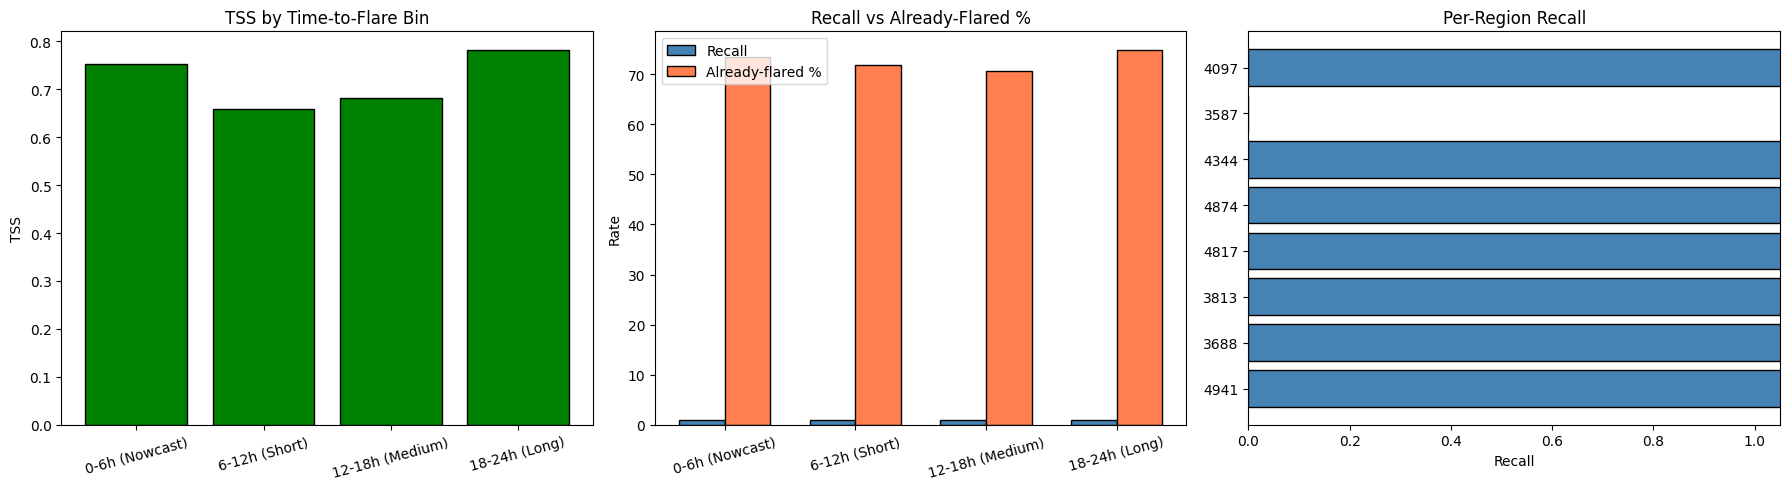


✅ Saved: time_to_flare_stratification.png

✅ Stratification complete.


In [5]:
# =============================================================================
# TIME-TO-FLARE STRATIFICATION + ALREADY-FLARED CONFOUND + PER-REGION AUDIT
# =============================================================================
# Run this as a SINGLE cell in your existing notebook (after all imports).
# It rebuilds the exact same seed-35 split, loads the XGB model,
# and produces every diagnostic table/plot you need for the paper.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, roc_curve, average_precision_score
import warnings
warnings.filterwarnings("ignore")

# ==========================
# CONFIG
# ==========================
DATA_FILE   = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
MODEL_FILE  = "best_xgb_params_updated_study.joblib"
FLARE_DIR   = "raw_flare_data_parquet"
GROUP_COL    = "HARPNUM"
LABEL_COL    = "flare"
RANDOM_STATE = 35
TEST_FRAC    = 0.10
ROLLING_SUFFIXES = ('_mean3', '_std3', '_min3', '_max3', '_slope3')

# ==========================
# 1. LOAD DATA + SPLIT (identical to training)
# ==========================
print("--- 1. Loading data and recreating split ---")
df = pd.read_parquet(DATA_FILE)
df['T_REC'] = pd.to_datetime(df['T_REC'])

exclude = {LABEL_COL, GROUP_COL, 'classification', 'NOAA_AR', 'T_REC'}
feat_cols = [c for c in df.select_dtypes(include=['number']).columns
             if c not in exclude and not c.endswith(ROLLING_SUFFIXES)]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df[LABEL_COL], groups=df[GROUP_COL]))
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

print(f"Features: {len(feat_cols)}")
print(f"Test set: {len(test_df)} rows, {int(test_df[LABEL_COL].sum())} positives")

# ==========================
# 2. LOAD MODEL
# ==========================
print("\n--- 2. Loading model ---")
bundle = joblib.load(MODEL_FILE)
model  = bundle["model"]
scaler = bundle["scaler"]
saved_features = bundle["features"]

# Use the features the model was actually trained on
X_test = scaler.transform(test_df[saved_features].values)
y_test = test_df[LABEL_COL].values
y_probs = model.predict_proba(X_test)[:, 1]
print(f"Model loaded. Predictions generated.")

# ==========================
# 3. LOAD GOES FLARE CATALOG + MATCH TO POSITIVE RECORDS
# ==========================
print("\n--- 3. Matching positive records to GOES flare events ---")
import glob, os

flare_files = sorted(glob.glob(os.path.join(FLARE_DIR, "*.parquet")))
flares = pd.concat([pd.read_parquet(f) for f in flare_files], ignore_index=True)
flares['event_starttime'] = pd.to_datetime(flares['event_starttime'])
flares = flares[flares['fl_goescls'].str.startswith(('M', 'X'))].copy()
flares = flares.sort_values('event_starttime').reset_index(drop=True)

print(f"M/X flares in catalog: {len(flares)}")

# Match each positive test record to the EARLIEST M/X flare in its 24h window
window = pd.Timedelta(hours=24)
pos_mask = test_df[LABEL_COL] == 1
pos_df = test_df[pos_mask].copy()

time_to_flare = np.full(len(pos_df), np.nan)
matched_flare_class = pd.Series(index=pos_df.index, dtype=str)
already_flared_flag = np.zeros(len(pos_df), dtype=bool)

# Pre-group flares by NOAA_AR for speed
flare_by_ar = {ar: group for ar, group in flares.groupby('ar_noaanum')}

for i, (idx, row) in enumerate(pos_df.iterrows()):
    t_rec = row['T_REC']
    ar = row.get('NOAA_AR', None)
    
    if ar is None or pd.isna(ar):
        continue
    
    ar_flares = flare_by_ar.get(ar, pd.DataFrame())
    if ar_flares.empty:
        continue
    
    # Find flares in [T_REC, T_REC + 24h)
    in_window = ar_flares[
        (ar_flares['event_starttime'] >= t_rec) &
        (ar_flares['event_starttime'] < t_rec + window)
    ]
    
    if not in_window.empty:
        earliest = in_window.iloc[0]
        time_to_flare[i] = (earliest['event_starttime'] - t_rec).total_seconds() / 3600.0
        matched_flare_class[idx] = earliest['fl_goescls']
    
    # Check if this AR had a PRIOR M/X flare BEFORE this record
    prior = ar_flares[ar_flares['event_starttime'] < t_rec]
    if not prior.empty:
        already_flared_flag[i] = True

pos_df['time_to_flare_h'] = time_to_flare
pos_df['matched_class'] = matched_flare_class
pos_df['already_flared'] = already_flared_flag

matched_count = pos_df['time_to_flare_h'].notna().sum()
print(f"Matched {matched_count}/{len(pos_df)} positive records to a flare event.")
print(f"Already-flared flag: {already_flared_flag.sum()}/{len(pos_df)}")

# ==========================
# 4. BIN BY TIME-TO-FLARE
# ==========================
print("\n--- 4. Time-to-flare stratification ---")
bins = [(0, 6, "0-6h (Nowcast)"), (6, 12, "6-12h (Short)"),
        (12, 18, "12-18h (Medium)"), (18, 24, "18-24h (Long)")]

# We need predictions for ALL test records to compute FPR correctly
# FPR denominator = all negative test records (shared across bins)
neg_mask = test_df[LABEL_COL] == 0
neg_probs = y_probs[neg_mask.values]

print(f"\n{'Bin':<22} {'N':>6} {'TP':>6} {'FN':>6} {'Recall':>8} {'FPR':>8} {'TSS':>8} {'AlreadyFlared%':>15}")
print("-" * 95)

bin_results = []
for lo, hi, label in bins:
    in_bin = pos_df[(pos_df['time_to_flare_h'] >= lo) & (pos_df['time_to_flare_h'] < hi)]
    if len(in_bin) == 0:
        print(f"{label:<22} {'0':>6} {'--':>6} {'--':>6} {'--':>8} {'--':>8} {'--':>8} {'--':>15}")
        continue
    
    bin_probs = y_probs[in_bin.index]
    # Use the model's stored threshold or 0.5
    thresh = bundle.get("threshold", 0.5)
    bin_preds = (bin_probs >= thresh).astype(int)
    
    tp = int(bin_preds.sum())
    fn = len(in_bin) - tp
    recall = tp / len(in_bin) if len(in_bin) > 0 else 0
    
    # FPR: use same threshold on all negatives
    neg_preds = (neg_probs >= thresh).astype(int)
    fp = int(neg_preds.sum())
    tn = len(neg_probs) - fp
    fpr = fp / len(neg_probs) if len(neg_probs) > 0 else 0
    
    tss = recall - fpr
    af_pct = in_bin['already_flared'].mean() * 100
    
    print(f"{label:<22} {len(in_bin):>6} {tp:>6} {fn:>6} {recall:>8.4f} {fpr:>8.4f} {tss:>8.4f} {af_pct:>14.1f}%")
    bin_results.append({'bin': label, 'n': len(in_bin), 'tp': tp, 'fn': fn,
                        'recall': recall, 'fpr': fpr, 'tss': tss, 'af_pct': af_pct})

# ==========================
# 5. THRESHOLD SCAN PER BIN
# ==========================
print("\n--- 5. Optimal threshold per bin ---")
print(f"\n{'Bin':<22} {'BestThresh':>10} {'BestTSS':>8} {'Recall':>8} {'FPR':>8}")
print("-" * 70)

for lo, hi, label in bins:
    in_bin = pos_df[(pos_df['time_to_flare_h'] >= lo) & (pos_df['time_to_flare_h'] < hi)]
    if len(in_bin) == 0:
        continue
    bin_probs = y_probs[in_bin.index]
    
    best_t, best_tss = 0.5, -1
    for t in np.linspace(0.01, 0.99, 99):
        bp = (bin_probs >= t).astype(int)
        tp_b = int(bp.sum())
        fn_b = len(in_bin) - tp_b
        rec = tp_b / len(in_bin)
        
        neg_p = (neg_probs >= t).astype(int)
        fp_b = int(neg_p.sum())
        fpr_b = fp_b / len(neg_probs) if len(neg_probs) > 0 else 0
        tss_b = rec - fpr_b
        
        if tss_b > best_tss:
            best_tss, best_t = tss_b, t
    
    print(f"{label:<22} {best_t:>10.3f} {best_tss:>8.4f} {rec:>8.4f} {fpr_b:>8.4f}")

# ==========================
# 6. ALREADY-FLARED CONFOUND BREAKDOWN
# ==========================
print("\n--- 6. Already-flared confound ---")
for lo, hi, label in bins:
    in_bin = pos_df[(pos_df['time_to_flare_h'] >= lo) & (pos_df['time_to_flare_h'] < hi)]
    if len(in_bin) == 0:
        continue
    af = in_bin['already_flared'].mean() * 100
    n_af = int(in_bin['already_flared'].sum())
    print(f"  {label:<22}: {n_af}/{len(in_bin)} ({af:.1f}%) had a prior M/X flare")

# ==========================
# 7. PER-REGION AUDIT
# ==========================
print("\n--- 7. Per-region audit ---")
thresh = bundle.get("threshold", 0.5)
test_df['pred'] = (y_probs >= thresh).astype(int)

region_stats = []
for harp in test_df[GROUP_COL].unique():
    rmask = test_df[GROUP_COL] == harp
    rdata = test_df[rmask]
    if rdata[LABEL_COL].sum() == 0:
        continue
    tp_r = int((rdata['pred'] == 1).sum())
    total_pos = int(rdata[LABEL_COL].sum())
    rec_r = tp_r / total_pos if total_pos > 0 else 0
    region_stats.append({'HARPNUM': harp, 'total_pos': total_pos, 'tp': tp_r, 'recall': rec_r})

region_df = pd.DataFrame(region_stats).sort_values('total_pos', ascending=False)
print(f"\n{'HARPNUM':>10} {'TotalPos':>10} {'TP':>6} {'Recall':>8}")
print("-" * 50)
for _, row in region_df.iterrows():
    print(f"{int(row['HARPNUM']):>10} {int(row['total_pos']):>10} {int(row['tp']):>6} {row['recall']:>8.4f}")

# ==========================
# 8. PLOTS
# ==========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: TSS per bin
bin_labels = [r['bin'] for r in bin_results if r['n'] > 0]
bin_tss = [r['tss'] for r in bin_results if r['n'] > 0]
colors = ['red' if t < 0.2 else 'orange' if t < 0.4 else 'green' for t in bin_tss]
axes[0].bar(bin_labels, bin_tss, color=colors, edgecolor='black')
axes[0].set_ylabel("TSS")
axes[0].set_title("TSS by Time-to-Flare Bin")
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=15)

# Plot B: Recall per bin with already-flared %
bin_rec = [r['recall'] for r in bin_results if r['n'] > 0]
bin_af = [r['af_pct'] for r in bin_results if r['n'] > 0]
x = np.arange(len(bin_labels))
w = 0.35
axes[1].bar(x - w/2, bin_rec, w, label='Recall', color='steelblue', edgecolor='black')
axes[1].bar(x + w/2, bin_af, w, label='Already-flared %', color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=15)
axes[1].set_ylabel("Rate")
axes[1].set_title("Recall vs Already-Flared %")
axes[1].legend()

# Plot C: Per-region recall
axes[2].barh(region_df['HARPNUM'].astype(str), region_df['recall'], color='steelblue', edgecolor='black')
axes[2].set_xlabel("Recall")
axes[2].set_title("Per-Region Recall")
axes[2].set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig("time_to_flare_stratification.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved: time_to_flare_stratification.png")
print("\n✅ Stratification complete.")

In [14]:
first_flare = pos_df[~pos_df['already_flared']]
thresh = bundle.get("threshold", 0.5)
for lo, hi, label in bins:
    in_bin = first_flare[(first_flare['time_to_flare_h'] >= lo) &
                         (first_flare['time_to_flare_h'] < hi)]
    if len(in_bin) == 0:
        continue
    hit = (y_probs[in_bin.index] >= thresh).mean()
    print(f"{label:<22} n={len(in_bin):4d}  recall={hit:.4f}")

0-6h (Nowcast)         n= 128  recall=0.8906
6-12h (Short)          n= 122  recall=0.5656
12-18h (Medium)        n=  85  recall=0.6588
18-24h (Long)          n=  67  recall=1.0000


In [7]:
import numpy as np, pandas as pd, glob, os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

DATA_FILE   = "final_arsenal_300_features_OPTIMIZED_updated.parquet"
FLARE_DIR   = "raw_flare_data_parquet"
GROUP_COL, LABEL_COL = "HARPNUM", "flare"
RANDOM_STATE, TEST_FRAC = 35, 0.10

# 1. Rebuild the exact seed-35 test set
df = pd.read_parquet(DATA_FILE)
df['T_REC'] = pd.to_datetime(df['T_REC'])
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df[LABEL_COL], groups=df[GROUP_COL]))
train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].reset_index(drop=True).copy()

# 2. M/X flare catalog, per-AR sorted start times
flares = pd.concat([pd.read_parquet(f) for f in sorted(glob.glob(os.path.join(FLARE_DIR, "*.parquet")))],
                   ignore_index=True)
flares['event_starttime'] = pd.to_datetime(flares['event_starttime'])
flares = flares[flares['fl_goescls'].str.startswith(('M', 'X'))]
flare_times = {ar: np.sort(g['event_starttime'].values) for ar, g in flares.groupby('ar_noaanum')}

# 3. already-flared flag for EVERY test record (flare strictly before T_REC)
def already_flared(ar, t):
    times = flare_times.get(ar)
    if times is None or len(times) == 0:
        return False
    return np.searchsorted(times, np.datetime64(t), side='left') > 0

test_df['already_flared'] = [already_flared(ar, t)
                             for ar, t in zip(test_df['NOAA_AR'], test_df['T_REC'])]

# 4. Static baselines (thresholds from TRAIN only)
usflux_thresh = train_df['USFLUX'].median()
y = test_df[LABEL_COL].values

baselines = {
    "already-flared only":            test_df['already_flared'].astype(int).values,
    f"USFLUX > train median":         (test_df['USFLUX'] > usflux_thresh).astype(int).values,
    "already-flared OR USFLUX":       ((test_df['already_flared']) |
                                       (test_df['USFLUX'] > usflux_thresh)).astype(int).values,
}

def report(name, y_pred):
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr    = fp / (fp + tn) if (fp + tn) else 0.0
    prec   = tp / (tp + fp) if (tp + fp) else 0.0
    print(f"{name:<26} TSS={recall - fpr:.4f}  recall={recall:.4f}  "
          f"FPR={fpr:.4f}  precision={prec:.4f}  FP={fp}")

print(f"test positives: {y.sum()} / {len(y)}")
for name, pred in baselines.items():
    report(name, pred)

print("\nReference (leak-free models): XGB TSS=0.6450 | BRF TSS=0.6499")

test positives: 1468 / 61575
already-flared only        TSS=0.1947  recall=0.7262  FPR=0.5315  precision=0.0323  FP=31944
USFLUX > train median      TSS=0.4622  recall=1.0000  FPR=0.5378  precision=0.0434  FP=32327
already-flared OR USFLUX   TSS=0.0793  recall=1.0000  FPR=0.9207  precision=0.0258  FP=55341

Reference (leak-free models): XGB TSS=0.6450 | BRF TSS=0.6499
